# F1 Podium Predictor

For this one, we need the MLFlow server running from now on. We need a virtual environment now for this so what we do is we run the following to create a virtual environment:
```
python3 -m venv .venv
```

Activate it:
```
source .venv/bin/activate
```

Install mlflow into it:
```
pip install mlflow
```

Then, from now on we can make sure that the MLFLow server is running whenever we do any training. The extra options here just set the local file locations:
```
mlflow server \
  --backend-store-uri sqlite:///mlruns.db \
  --default-artifact-root ./mlartifacts \
  --host 127.0.0.1 \
  --port 5000
  ```

## Importing the Libraries

In [2]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.metrics import roc_auc_score, brier_score_loss, RocCurveDisplay, roc_curve
from sklearn.calibration import calibration_curve

In [3]:
# Be aware, you'll need MLFlow running in the background here otherwise this will fail
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("f1-podium-predictor")

2026/05/01 09:07:55 INFO mlflow.tracking.fluent: Experiment with name 'f1-podium-predictor' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/dave/Work/F1Predictor/notebooks/mlartifacts/1', creation_time=1777622875643, experiment_id='1', last_update_time=1777622875643, lifecycle_stage='active', name='f1-podium-predictor', tags={}, trace_location=None, workspace='default'>

## Loading in the Data

In [4]:
race_df = pd.read_csv("../data/races.csv", na_values="\\N", parse_dates=["date", "quali_date"])
race_df.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [5]:
res_df = pd.read_csv("../data/results.csv", na_values="\\N")
res_df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11.0,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3.0,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [6]:
constructor_df = pd.read_csv("../data/constructors.csv")
constructor_df.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [7]:
drivers_df = pd.read_csv("../data/drivers.csv", na_values="\\N", parse_dates=["dob"])
drivers_df.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [8]:
status_df = pd.read_csv("../data/status.csv", na_values="\\N")
status_df.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [9]:
circuit_df = pd.read_csv("../data/circuits.csv")
circuit_df.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


## Setting up the Base Dataframe

In [10]:
full_base_race_data_df = pd.merge(
    left=res_df[["resultId", "raceId","driverId", "constructorId", "position", "statusId"]],
    right=race_df[["raceId","year","round","circuitId","name","date"]],
    on="raceId"
)

full_base_race_data_df = pd.merge(
    left=full_base_race_data_df,
    right=drivers_df[["driverId","dob","nationality"]],
    on="driverId"
)

full_base_race_data_df["podiumFinish"] = (full_base_race_data_df["position"] <= 3).astype(int)
full_base_race_data_df = full_base_race_data_df[full_base_race_data_df["year"] > 1990]

full_base_race_data_df

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish
0,1,18,1,1,1.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-01-07,British,1
1,2,18,2,2,2.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1977-05-10,German,1
2,3,18,3,3,3.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-06-27,German,1
3,4,18,4,4,4.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-07-29,Spanish,0
4,5,18,5,1,5.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-10-19,Finnish,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27299,27305,1171,4,117,18.0,11,2026,3,22,Japanese Grand Prix,2026-03-29,1981-07-29,Spanish,0
27300,27306,1171,822,216,19.0,11,2026,3,22,Japanese Grand Prix,2026-03-29,1989-08-28,Finnish,0
27301,27307,1171,848,3,20.0,12,2026,3,22,Japanese Grand Prix,2026-03-29,1996-03-23,Thai,0
27302,27308,1171,840,117,21.0,34,2026,3,22,Japanese Grand Prix,2026-03-29,1998-10-29,Canadian,0


In [11]:
training_base_race_data_df = full_base_race_data_df[full_base_race_data_df["year"] < 2025].copy()
training_base_race_data_df

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish
0,1,18,1,1,1.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-01-07,British,1
1,2,18,2,2,2.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1977-05-10,German,1
2,3,18,3,3,3.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-06-27,German,1
3,4,18,4,4,4.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-07-29,Spanish,0
4,5,18,5,1,5.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-10-19,Finnish,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,26760,1144,825,210,16.0,11,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,1992-10-05,Danish,0
26755,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2002-02-11,New Zealander,0
26756,26762,1144,822,15,NaN,130,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,1989-08-28,Finnish,0
26757,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2003-05-27,Argentinian,0


In [12]:
base_features = ["driverId", "constructorId", "circuitId", "year", "round"]
base_cat_features = ["driverId", "constructorId", "circuitId"]

for col in base_cat_features:
    training_base_race_data_df[col] = training_base_race_data_df[col].astype("category")

X = training_base_race_data_df[base_features]
y = training_base_race_data_df["podiumFinish"]

In [13]:
train_mask = training_base_race_data_df["year"] <= 2023
val_mask   = (training_base_race_data_df["year"] > 2023) & (training_base_race_data_df["year"] < 2025)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

Retraining the model to get it into MLFlow

In [14]:
with mlflow.start_run(run_name="lgbm-baseline", description="Minimal feature set, no engineering"):
    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        verbose=-1
    )
    model.fit(X_train, y_train)
    
    preds = model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, preds)
    brier = brier_score_loss(y_val, preds)
    
    mlflow.set_tags({
        "model_type": "lightgbm",
        "feature_set": "baseline",
        "data_version": "1990-2024"
    })

    train_dataset = mlflow.data.from_pandas(
        training_base_race_data_df[train_mask], 
        name="f1-results-train", 
        targets="podiumFinish"
    )

    val_dataset = mlflow.data.from_pandas(
        training_base_race_data_df[val_mask], 
        name="f1-results-val", 
        targets="podiumFinish"
    )

    fig, ax = plt.subplots()
    
    fpr, tpr, _ = roc_curve(y_val, preds)
    
    ax.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("ROC Curve - LightGBM Baseline")
    ax.legend(loc="lower right")
    
    mlflow.log_figure(fig, "roc_curve.png")
    plt.close(fig)

    mlflow.log_input(train_dataset, context="training")
    mlflow.log_input(val_dataset, context="validation")

    mlflow.log_params(model.get_params())
    mlflow.log_metric("val_roc_auc", auc)
    mlflow.log_metric("val_brier_score", brier)
    
    mlflow.lightgbm.log_model(model, name="lgbm-podium-predictor-baseline")

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/05/01 09:07:57 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrar

🏃 View run lgbm-baseline at: http://127.0.0.1:5000/#/experiments/1/runs/c096ff0405b04f13bbbb7c6ad0bf159e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Implementing Walk Forward Validation

At the moment, we're using one validation set (the 2025 data) but we can actually do better than this. 

* Random-K folds: Doesn't work for our use case at all, if we randomly split the data into K sets then we're leaking future data into the current training.
* Expanding window/TimeSeriesSplit: This is better, but the training set doesn't have a stable size so we're adding more and more recent data into each split which means that the results can potentially behave differently but for different reasons other than the validation performance
* Rolling window splits: The best option for us, we define a window - say 10 races. We then slide this window over the years of data using the most recent one in that window as the validation. This is great because old seasons gradually age out, the windows are the same size the whole way through. Old data aging out might be a problem but it's quite likely that in our scenario, data from 1990 has little say in the race results of today so we're not too worried about that

In [15]:
# First up, before we do anything let's make a copy
training_base_fold_race_data_df = training_base_race_data_df.copy()

In [16]:
years = sorted(training_base_race_data_df["year"].unique())

train_window = 10   # The number of seasons in each training fold 
val_window = 1      # The number of season to run the validation on

folds = []

for i in range(len(years) - train_window - val_window + 1):
    train_years = years[i: i + train_window]
    val_years = years[i + train_window: i + train_window + val_window]
    folds.append((train_years, val_years))

pd.DataFrame(folds, columns=["TrainYears", "ValYears"])

,TrainYears,ValYears
0,"[1991, 1992, 1993, 1994, 1995, 1996, 1997, 199...",[2001]
1,"[1992, 1993, 1994, 1995, 1996, 1997, 1998, 199...",[2002]
2,"[1993, 1994, 1995, 1996, 1997, 1998, 1999, 200...",[2003]
3,"[1994, 1995, 1996, 1997, 1998, 1999, 2000, 200...",[2004]
4,"[1995, 1996, 1997, 1998, 1999, 2000, 2001, 200...",[2005]
5,"[1996, 1997, 1998, 1999, 2000, 2001, 2002, 200...",[2006]
6,"[1997, 1998, 1999, 2000, 2001, 2002, 2003, 200...",[2007]
7,"[1998, 1999, 2000, 2001, 2002, 2003, 2004, 200...",[2008]
8,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",[2009]
9,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[2010]


In [17]:
for fold, (train_years, val_years) in enumerate(folds):
    train_mask = training_base_race_data_df["year"].isin(train_years)
    val_mask   = training_base_race_data_df["year"].isin(val_years)
    
    X_train_fold, y_train_fold = X[train_mask], y[train_mask]
    X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]

In [18]:
with mlflow.start_run(run_name="lgbm-baseline-walk-forward", description="Baseline LightGBM with rolling walk-forward cross-validation, no feature engineering") as parent_run:
    mlflow.set_tags({
        "model_type": "lightgbm",
        "feature_set": "baseline",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    })

    fold_aucs, fold_briers = [], []
    all_preds, all_labels = [], []

    for fold, (train_years, val_years) in enumerate(folds):
        train_mask = training_base_race_data_df["year"].isin(train_years)
        val_mask   = training_base_race_data_df["year"].isin(val_years)

        X_train_fold, y_train_fold = X[train_mask], y[train_mask]
        X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]

        with mlflow.start_run(run_name=f"lgbm-baseline-fold-{fold}", nested=True):
            train_dataset = mlflow.data.from_pandas(
                training_base_race_data_df[train_mask],
                name=f"f1-results-train-fold-{fold}",
                targets="podiumFinish"
            )
            val_dataset = mlflow.data.from_pandas(
                training_base_race_data_df[val_mask],
                name=f"f1-results-val-fold-{fold}",
                targets="podiumFinish"
            )
            mlflow.log_input(train_dataset, context="training")
            mlflow.log_input(val_dataset, context="validation")

            model = lgb.LGBMClassifier(
                objective="binary",
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                min_child_samples=20,
                verbose=-1
            )
            model.fit(X_train_fold, y_train_fold)
            preds = model.predict_proba(X_val_fold)[:, 1]

            all_preds.extend(preds)
            all_labels.extend(y_val_fold)

            fold_auc   = roc_auc_score(y_val_fold, preds)
            fold_brier = brier_score_loss(y_val_fold, preds)
            fold_aucs.append(fold_auc)
            fold_briers.append(fold_brier)

            mlflow.log_param("train_years", f"{train_years[0]}-{train_years[-1]}")
            mlflow.log_param("val_year", val_years[0])
            mlflow.log_metric("val_roc_auc", fold_auc)
            mlflow.log_metric("val_brier_score", fold_brier)

    agg_auc = roc_auc_score(all_labels, all_preds)

    mlflow.log_metric("mean_val_roc_auc", np.mean(fold_aucs))
    mlflow.log_metric("mean_val_brier_score", np.mean(fold_briers))
    mlflow.log_metric("agg_val_roc_auc", agg_auc)
    mlflow.log_params(model.get_params())

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots()
        fpr, tpr, _ = roc_curve(all_labels, all_preds)
        ax.plot(fpr, tpr, label=f"ROC curve (AUC = {agg_auc:.2f})")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title("ROC Curve - LightGBM Baseline (all folds)")
        ax.legend(loc="lower right")
        mlflow.log_figure(fig, "roc_curve.png")
        plt.close(fig)

    mlflow.lightgbm.log_model(model, name="lgbm-podium-walking-predictor-baseline")

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/0e1d91dc2be34cbbad6157e10629fe96
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/58e255430cfd4ea09305a04f7404e5de
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/a2e80ebb2cf549ad95b72e26d9da3996
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/f5bab819761744968402fe22315e7030
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/01 09:08:16 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-baseline-walk-forward at: http://127.0.0.1:5000/#/experiments/1/runs/e942f7d84a434a8e9a780ab1c0802a47
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


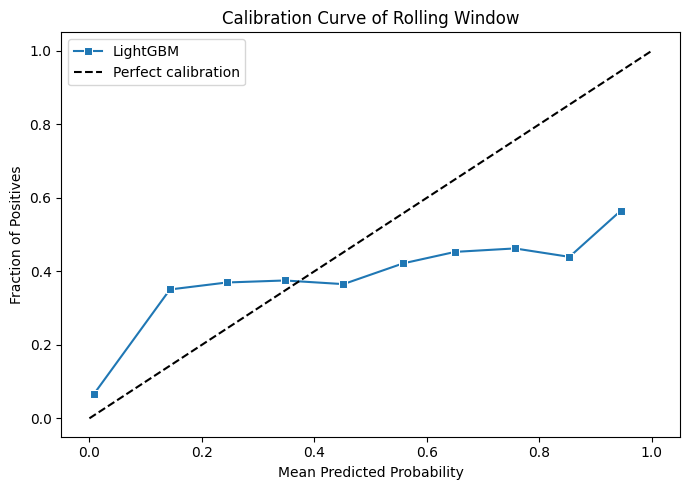

In [19]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

fraction_of_positives, mean_predicted_value = calibration_curve(
    all_labels, all_preds, n_bins=10
)

calib_df = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Fraction of Positives": fraction_of_positives
})

fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.lineplot(
    data=calib_df,
    x="Mean Predicted Probability",
    y="Fraction of Positives",
    marker="s", label="LightGBM", ax=ax1
)
ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax1.set_title("Calibration Curve of Rolling Window")
ax1.legend()
plt.tight_layout()
plt.show()

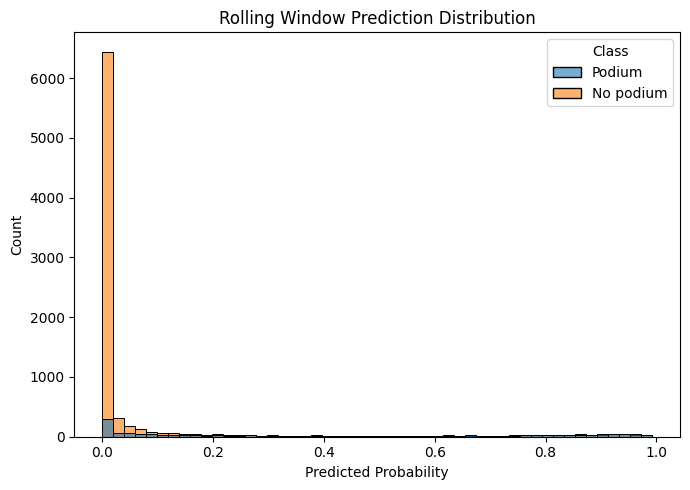

In [20]:
dist_df = pd.DataFrame({
    "Predicted Probability": all_preds,
    "Class": ["Podium" if y == 1 else "No podium" for y in all_labels]
})

fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.histplot(
    data=dist_df,
    x="Predicted Probability",
    hue="Class",
    bins=50,
    alpha=0.6,
    ax=ax2
)
ax2.set_title("Rolling Window Prediction Distribution")
plt.tight_layout()
plt.show()

## Addressing the Imbalance

In [21]:
with mlflow.start_run(run_name="lgbm-baseline-walk-forward-scaled", description="Baseline LightGBM with rolling walk-forward cross-validation, no feature engineering") as parent_run:
    mlflow.set_tags({
        "model_type": "lightgbm",
        "feature_set": "baseline",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    })

    fold_aucs, fold_briers = [], []
    all_preds, all_labels = [], []

    for fold, (train_years, val_years) in enumerate(folds):
        train_mask = training_base_race_data_df["year"].isin(train_years)
        val_mask   = training_base_race_data_df["year"].isin(val_years)

        X_train_fold, y_train_fold = X[train_mask], y[train_mask]
        X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]

        with mlflow.start_run(run_name=f"lgbm-baseline-fold-{fold}", nested=True):
            train_dataset = mlflow.data.from_pandas(
                training_base_race_data_df[train_mask],
                name=f"f1-results-train-fold-{fold}",
                targets="podiumFinish"
            )
            val_dataset = mlflow.data.from_pandas(
                training_base_race_data_df[val_mask],
                name=f"f1-results-val-fold-{fold}",
                targets="podiumFinish"
            )
            mlflow.log_input(train_dataset, context="training")
            mlflow.log_input(val_dataset, context="validation")

            model = lgb.LGBMClassifier(
                objective="binary",
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                min_child_samples=20,
                scale_pos_weight=5.67,
                verbose=-1,
            )
            model.fit(X_train_fold, y_train_fold)
            preds = model.predict_proba(X_val_fold)[:, 1]

            all_preds.extend(preds)
            all_labels.extend(y_val_fold)

            fold_auc   = roc_auc_score(y_val_fold, preds)
            fold_brier = brier_score_loss(y_val_fold, preds)
            fold_aucs.append(fold_auc)
            fold_briers.append(fold_brier)

            mlflow.log_param("train_years", f"{train_years[0]}-{train_years[-1]}")
            mlflow.log_param("val_year", val_years[0])
            mlflow.log_metric("val_roc_auc", fold_auc)
            mlflow.log_metric("val_brier_score", fold_brier)

    agg_auc = roc_auc_score(all_labels, all_preds)

    mlflow.log_metric("mean_val_roc_auc", np.mean(fold_aucs))
    mlflow.log_metric("mean_val_brier_score", np.mean(fold_briers))
    mlflow.log_metric("agg_val_roc_auc", agg_auc)
    mlflow.log_params(model.get_params())

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots()
        fpr, tpr, _ = roc_curve(all_labels, all_preds)
        ax.plot(fpr, tpr, label=f"ROC curve (AUC = {agg_auc:.2f})")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title("ROC Curve - LightGBM Baseline Scaled (all folds)")
        ax.legend(loc="lower right")
        mlflow.log_figure(fig, "roc_curve.png")
        plt.close(fig)

    mlflow.lightgbm.log_model(model, name="lgbm-podium-walking-predictor-scaled-baseline")

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/0492b9f703b64e76a76747056d0ed238
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/6bafe54e04c2454a9c01784d410d37f1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/5aa98f7b91e8464aafd85f18d324b1ea
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/37da43044f0146519b287001063b8687
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/01 09:08:35 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-baseline-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/0f3ed0a4b13d4c429dfd1eb30428d0cc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


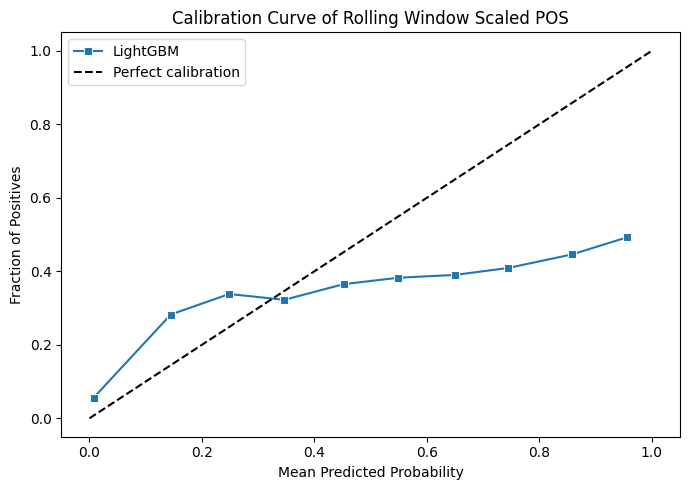

In [22]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

fraction_of_positives, mean_predicted_value = calibration_curve(
    all_labels, all_preds, n_bins=10
)

calib_df = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Fraction of Positives": fraction_of_positives
})

fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.lineplot(
    data=calib_df,
    x="Mean Predicted Probability",
    y="Fraction of Positives",
    marker="s", label="LightGBM", ax=ax1
)
ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax1.set_title("Calibration Curve of Rolling Window Scaled POS")
ax1.legend()
plt.tight_layout()
plt.show()

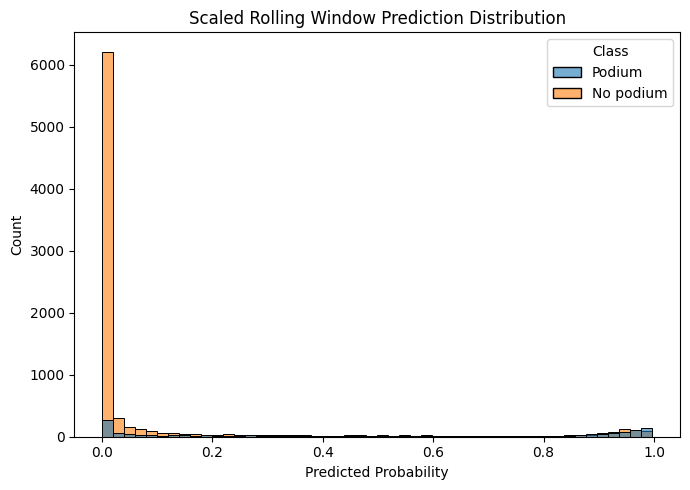

In [23]:
dist_df = pd.DataFrame({
    "Predicted Probability": all_preds,
    "Class": ["Podium" if y == 1 else "No podium" for y in all_labels]
})

fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.histplot(
    data=dist_df,
    x="Predicted Probability",
    hue="Class",
    bins=50,
    alpha=0.6,
    ax=ax2
)
ax2.set_title("Scaled Rolling Window Prediction Distribution")
plt.tight_layout()
plt.show()

## Feature time

### Convenience Methods

Okay! Because we've got our general setup now for how we generate folds, and also the general setup for how we train as well. We're gonna set up some convenience functions here just so that we can call these instead of having to define them every single time

In [24]:
def GenerateFolds(dataframe, train_window, val_window):
	"""
    Generates walk-forward cross-validation folds based on season years.

    Args:
        dataframe: DataFrame containing a 'year' column used to derive the fold splits.
        train_window: Number of seasons to include in each training fold.
        val_window: Number of seasons to include in each validation fold.

    Returns:
        List of (train_years, val_years) tuples, one per fold.
    """
	years = sorted(dataframe["year"].unique())

	folds = []

	for i in range(len(years) - train_window - val_window + 1):
		train_years = years[i: i + train_window]
		val_years = years[i + train_window: i + train_window + val_window]
		folds.append((train_years, val_years))
	    
	return folds

def GenXy(dataFrame, engineered_features, engineered_cat_features):
    """
    Prepares feature matrix X and target vector y from a DataFrame.
    Casts categorical columns to the 'category' dtype required by LightGBM.

    Args:
        dataFrame: DataFrame containing all features and the 'podiumFinish' target column.
        engineered_features: List of column names to use as model features.
        engineered_cat_features: Subset of engineered_features to cast to 'category' dtype.

    Returns:
        Tuple of (X, y) where X is the feature DataFrame and y is the binary target series.
    """
    for col in engineered_cat_features:
        dataFrame[col] = dataFrame[col].astype("category")
    
    X = dataFrame[engineered_features]
    y = dataFrame["podiumFinish"]
    
    return (X,y)
    
def TrainModel(X, y, dataFrame, folds, config):
	"""
	Runs walk-forward cross-validation and logs results to MLflow.
    Logs per-fold metrics to nested runs, and aggregate metrics, model params,
    ROC curve, and the final fold model artifact to the parent run.

    Args:
        X: Feature matrix, aligned with dataFrame's index.
        y: Binary target series (podiumFinish), aligned with dataFrame's index.
        dataFrame: Full DataFrame used for MLflow dataset logging and year-based fold masking.
        folds: List of (train_years, val_years) tuples as returned by GenerateFolds.
        config: Dict containing 'run_name', 'description', 'tags', and 'model_params'.
	
    Returns:
        Tuple of (model, all_preds, all_labels) where model is the trained LGBMClassifier
        from the final fold, all_preds are the predicted probabilities accumulated across
        all folds, and all_labels are the corresponding true binary labels.
	"""
	with mlflow.start_run(run_name=config["run_name"], description=config["description"]) as parent_run:
		mlflow.set_tags(config["tags"])
		
		fold_aucs, fold_briers = [], []
		all_preds, all_labels = [], []
		
		for fold, (train_years, val_years) in enumerate(folds):
			train_mask = dataFrame["year"].isin(train_years)
			val_mask   = dataFrame["year"].isin(val_years)
			
			X_train_fold, y_train_fold = X[train_mask], y[train_mask]
			X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]
			
			with mlflow.start_run(run_name=f"lgbm-baseline-fold-{fold}", nested=True):
				train_dataset = mlflow.data.from_pandas(
					dataFrame[train_mask],
					name=f"{config['run_name']}-train-fold-{fold}",
					targets="podiumFinish"
				)
				val_dataset = mlflow.data.from_pandas(
					dataFrame[val_mask],
					name=f"{config['run_name']}-val-fold-{fold}",
					targets="podiumFinish"
				)
				mlflow.log_input(train_dataset, context="training")
				mlflow.log_input(val_dataset, context="validation")
				
				model = lgb.LGBMClassifier(**config["model_params"])

				model.fit(X_train_fold, y_train_fold)
				preds = model.predict_proba(X_val_fold)[:, 1]

				all_preds.extend(preds)
				all_labels.extend(y_val_fold)
				
				fold_auc   = roc_auc_score(y_val_fold, preds)
				fold_brier = brier_score_loss(y_val_fold, preds)
				fold_aucs.append(fold_auc)
				fold_briers.append(fold_brier)
				
				mlflow.log_param("train_years", f"{train_years[0]}-{train_years[-1]}")
				mlflow.log_param("val_year", val_years[0])
				mlflow.log_metric("val_roc_auc", fold_auc)
				mlflow.log_metric("val_brier_score", fold_brier)
		
		mlflow.log_metric("mean_val_roc_auc", sum(fold_aucs) / len(fold_aucs))
		mlflow.log_metric("mean_val_brier_score", sum(fold_briers) / len(fold_briers))
		mlflow.log_params(model.get_params())
		
		with plt.style.context("dark_background"):
			fig, ax = plt.subplots()
			fpr, tpr, _ = roc_curve(y_val_fold, preds)
			ax.plot(fpr, tpr, label=f"ROC curve (AUC = {fold_auc:.2f})")
			ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
			ax.set_xlabel("False positive rate")
			ax.set_ylabel("True positive rate")
			ax.set_title("ROC Curve - LightGBM Baseline (final fold)")
			ax.legend(loc="lower right")
			mlflow.log_figure(fig, "roc_curve.png")
			plt.close(fig)
		
		mlflow.lightgbm.log_model(model, name=config["run_name"])
		
		return model, all_preds, all_labels 

def generateCalibrationGraph(cg_title, all_preds, all_labels):
	"""
	Plots a calibration curve comparing predicted probabilities to observed podium rates.

    Args:
        cg_title: Title string for the plot.
        all_preds: Array-like of predicted probabilities across all folds.
        all_labels: Array-like of true binary labels across all folds.
	"""
	all_preds = np.array(all_preds)
	all_labels = np.array(all_labels)

	fraction_of_positives, mean_predicted_value = calibration_curve(
        all_labels, all_preds, n_bins=10
    )
	
	calib_df = pd.DataFrame({
        "Mean Predicted Probability": mean_predicted_value,
        "Fraction of Positives": fraction_of_positives
    })

	_, ax1 = plt.subplots(figsize=(7, 5))
	sns.lineplot(
        data=calib_df,
        x="Mean Predicted Probability",
        y="Fraction of Positives",
        marker="s", label="LightGBM", ax=ax1
    )
	ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
	ax1.set_title(cg_title)
	ax1.legend()
	plt.tight_layout()
	plt.show()

def getROCAUCStats(all_preds, all_labels):
    """
    Computes ROC curve coordinates and summary evaluation metrics.
    Args:
        all_preds: Array-like of predicted probabilities across all folds.
        all_labels: Array-like of true binary labels across all folds.
    Returns:
        Tuple of (fpr, tpr, auc, brier) where fpr and tpr are arrays of ROC curve
        coordinates, auc is the area under the ROC curve, and brier is the Brier score.
    """
    fpr, tpr, _ = roc_curve(all_labels, all_preds)
    auc   = roc_auc_score(all_labels, all_preds)
    brier = brier_score_loss(all_labels, all_preds)
    return (fpr, tpr, auc, brier)

def ROCGraph(fpr, tpr, auc, roc_title):
    """
    Plots an ROC curve from precomputed false positive and true positive rates.
    Args:
        fpr: Array of false positive rates as returned by getROCAUCStats.
        tpr: Array of true positive rates as returned by getROCAUCStats.
        auc: AUC score as returned by getROCAUCStats, displayed in the legend.
        roc_title: Title string for the plot.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title(roc_title)
    plt.legend()
    plt.show()

def EvaluateModel(model, cg_title, roc_title, all_preds, all_labels):
	"""
	Runs the full evaluation suite for a trained LightGBM model.
    Plots feature importance (split and gain), calibration curve, and ROC curve,
    then prints AUC and Brier score against the project baselines.

    Args:
        model: Trained LGBMClassifier instance.
        cg_title: Title string for the calibration curve plot.
        roc_title: Title string for the ROC curve plot.
        all_preds: Array-like of predicted probabilities across all folds.
        all_labels: Array-like of true binary labels across all folds.
	"""
	lgb.plot_importance(model,importance_type='split', title='Feature Importance (Split)')
	lgb.plot_importance(model,importance_type='gain', title='Feature Importance (Gain)')

	generateCalibrationGraph(cg_title, all_preds, all_labels)

	fpr, tpr, auc, brier = getROCAUCStats(all_preds, all_labels)

	ROCGraph(fpr, tpr, auc, roc_title)

	print(f"AUC:   {auc:.4f}  (baseline: 0.79)")
	print(f"Brier: {brier:.4f}  (baseline: 0.12)")

### Rolling Driver Performance

In [25]:
training_base_driver_en_1_data_df = (
    training_base_race_data_df
    .sort_values(["driverId", "year", "round"])
    .copy()
)

training_base_driver_en_1_data_df["driver_podium_rate_3"] = (
    training_base_driver_en_1_data_df.groupby("driverId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

training_base_driver_en_1_data_df["driver_podium_rate_3"] = training_base_driver_en_1_data_df["driver_podium_rate_3"].fillna(0)
training_base_driver_en_1_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0


In [26]:
training_base_driver_en_1_data_df["driver_podium_rate_5"] = (
    training_base_driver_en_1_data_df.groupby("driverId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

training_base_driver_en_1_data_df["driver_podium_rate_5"] = training_base_driver_en_1_data_df["driver_podium_rate_5"].fillna(0)
training_base_driver_en_1_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0


In [27]:
training_base_driver_en_1_data_df["driver_podium_rate_10"] = (
    training_base_driver_en_1_data_df.groupby("driverId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

training_base_driver_en_1_data_df["driver_podium_rate_10"] = training_base_driver_en_1_data_df["driver_podium_rate_10"].fillna(0)
training_base_driver_en_1_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0,1.0


In [28]:
engineered_features = [
    "driverId", "constructorId", "circuitId", "year", "round",
    "driver_podium_rate_3", "driver_podium_rate_5", "driver_podium_rate_10"
]
engineered_cat_features = ["driverId", "constructorId", "circuitId"]

folds = GenerateFolds(training_base_driver_en_1_data_df, train_window=10, val_window=1)
X, y = GenXy(training_base_driver_en_1_data_df, engineered_features, engineered_cat_features)

In [29]:
model, all_preds, all_labels = TrainModel(X, y, training_base_driver_en_1_data_df, folds, {
    "run_name": "lgbm-driver-performance-walk-forward-scaled",
    "description": "LightGBM with rolling walk-forward cross-validation, and rolling driver performance",
    "tags": {
        "model_type": "lightgbm",
        "feature_set": "driverPerformance",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    },
    "model_params": {
        "objective": "binary",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 20,
        "scale_pos_weight": 5.67,
        "verbose": -1,
    }
})

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/95d359628a6342638dd73e64df0137c8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/9747ddd38547431295ec42efea4a43df
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/f54c3cd9460449d38d9264d2d599ddc3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/4d5e3652dd6146a4a6a4ce714a707cc5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/01 09:08:55 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-driver-performance-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/14fe2455d9ce4b54b817f67aad6d63e5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


#### Evaluating Driver Features

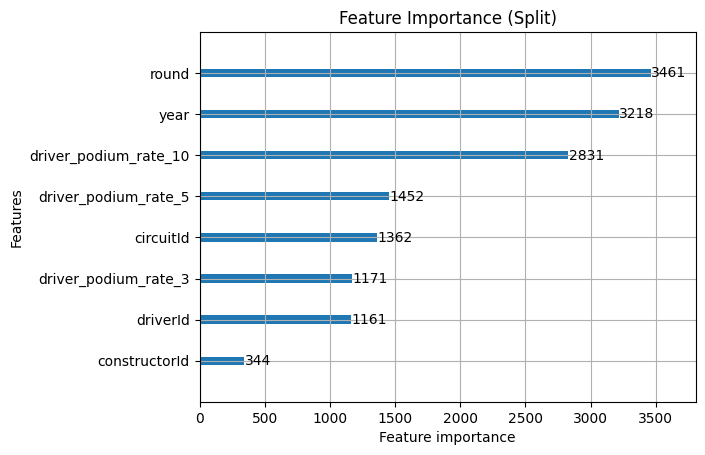

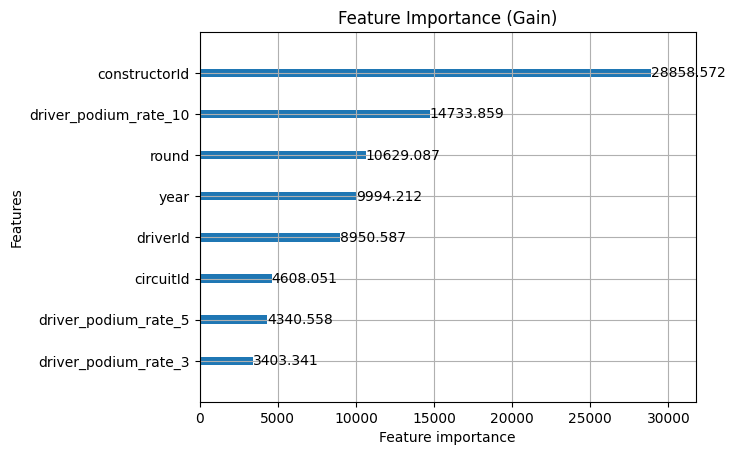

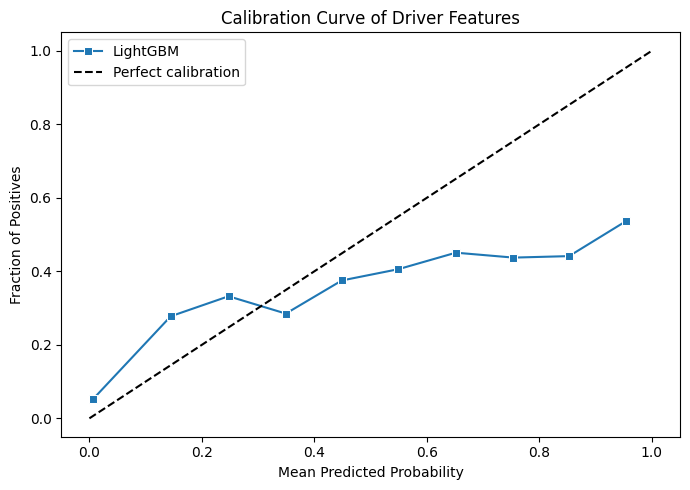

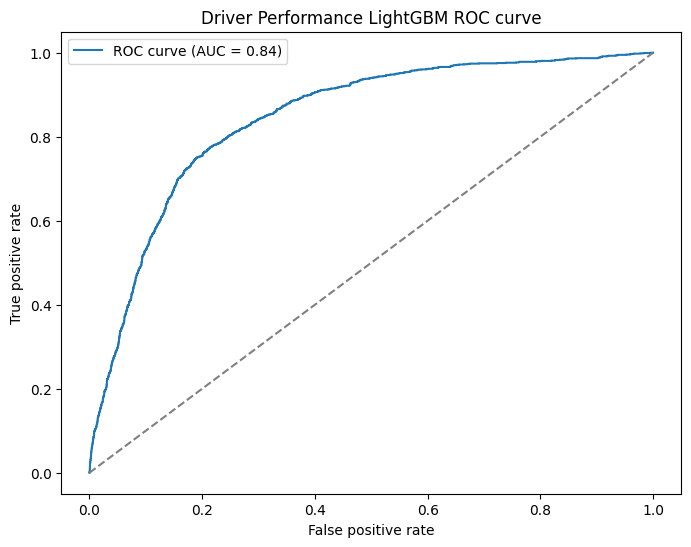

AUC:   0.8440  (baseline: 0.79)
Brier: 0.1174  (baseline: 0.12)


In [30]:
EvaluateModel(
    model, 
    all_labels=all_labels, 
    all_preds=all_preds, 
    cg_title="Calibration Curve of Driver Features", 
    roc_title="Driver Performance LightGBM ROC curve")


Okay interesting! So, we need to talk about Split vs Gain here:
* Split is how many times a feature was used as a split point across all trees, it's biaseed towards features that get used a lot even if they're not very important though e.g. if it's being used as a low level tie-breaker a lot
* Gain is a measure of how much the average improvement in the loss function was that a feature produced, it instead is biased towards high cardinality features e.g. constructor ID where yhou can do high-information splits early in the trees.

For example, constructor doesn't get used a lot (Low splits) but when it is used it's contributing a lot (high gain). So there is significant signal there

Round/year is different, theye're used a *lot* for splits but the value is mild so it's probaly using them more as a tie-breaker than for real value

Driver podium rate for the last 10 races though is *high for both* so it's used a lot AND it's genuinely performing well!

---

We can also see that year has dropped off significantly, our new features for rolling performance seems to be encoding very well "how well a driver is performing well right now" that was all being proxied by year. So, this is good news! We're untangling the mess of year

### Constructor Podium Rate

What do we build upon? We're going to build on top of the driver features that we just built. Why? Even though we might isolate the changes so that in theory we would only see how the constructor features perform this doesn't account for the interplay between features e.g. "Do the constructor features look better, because they're compensating for the driver features missing?"

We want to know *Do they add value above and beyond what the driver features give?*

In [31]:
training_base_driver_en_2_data_df = (
    training_base_driver_en_1_data_df
    .sort_values(["driverId", "year", "round"])
    .copy()
)

In [32]:
training_base_driver_en_2_data_df["constructor_podium_rate_3"] = (
    training_base_driver_en_2_data_df.groupby("constructorId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

training_base_driver_en_2_data_df["constructor_podium_rate_3"] = training_base_driver_en_2_data_df["constructor_podium_rate_3"].fillna(0)
training_base_driver_en_2_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0,1.0,1.0


In [33]:
training_base_driver_en_2_data_df["constructor_podium_rate_5"] = (
    training_base_driver_en_2_data_df.groupby("constructorId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

training_base_driver_en_2_data_df["constructor_podium_rate_5"] = training_base_driver_en_2_data_df["constructor_podium_rate_5"].fillna(0)
training_base_driver_en_2_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0,0.0,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0


In [34]:
training_base_driver_en_2_data_df["constructor_podium_rate_10"] = (
    training_base_driver_en_2_data_df.groupby("constructorId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

training_base_driver_en_2_data_df["constructor_podium_rate_10"] = training_base_driver_en_2_data_df["constructor_podium_rate_10"].fillna(0)
training_base_driver_en_2_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0,0.0,0.0,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0,1.0


#### Evaluating Constructor Features

In [35]:
engineered_features = [
    "driverId", "constructorId", "circuitId", "year", "round",
    "driver_podium_rate_3", "driver_podium_rate_5", "driver_podium_rate_10",
    "constructor_podium_rate_3", "constructor_podium_rate_5", "constructor_podium_rate_10"
]

engineered_cat_features = ["driverId", "constructorId", "circuitId"]

folds = GenerateFolds(training_base_driver_en_2_data_df, train_window=10, val_window=1)
X, y = GenXy(training_base_driver_en_2_data_df, engineered_features, engineered_cat_features)

In [36]:
model, all_preds, all_labels = TrainModel(X, y, training_base_driver_en_2_data_df, folds, {
    "run_name": "lgbm-constructor-performance-walk-forward-scaled",
    "description": "LightGBM with rolling walk-forward cross-validation, with driver and rolling constructor stats",
    "tags": {
        "model_type": "lightgbm",
        "feature_set": "driverPerformance + constructorPerformance",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    },
    "model_params": {
        "objective": "binary",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 20,
        "scale_pos_weight": 5.67,
        "verbose": -1,
    }
})

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/da802dcf0d0c47b98ab43471b48a168f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/812e6b93ae734a2e96b24b6a2535c5db
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/a6966821915c4bc7b3aa64687e03943e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/94d51566736348cfbb534e0798d91bad
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/01 09:09:15 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-constructor-performance-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/7fa7500665dd4963821f1785b823fa34
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


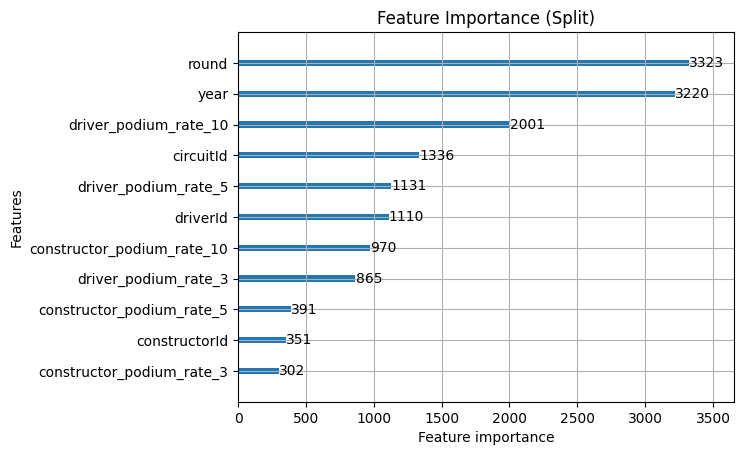

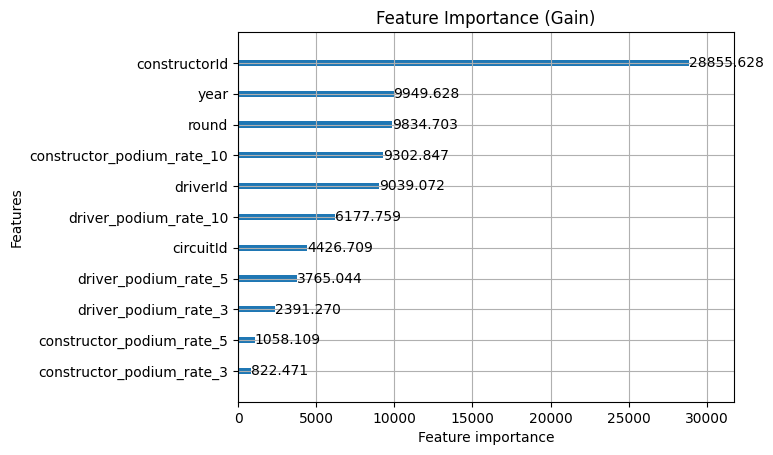

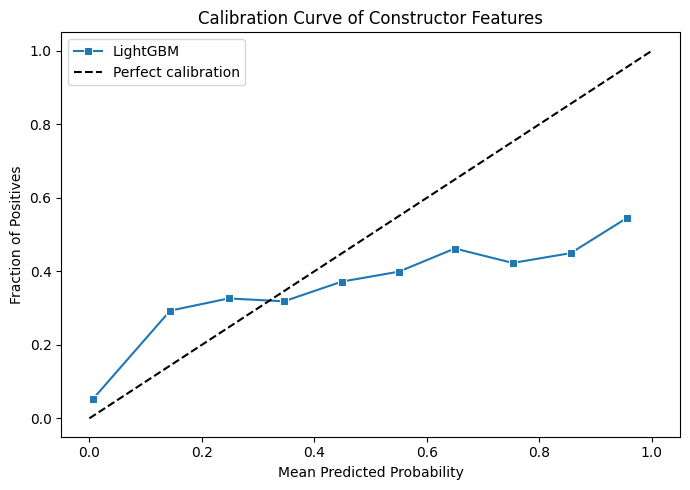

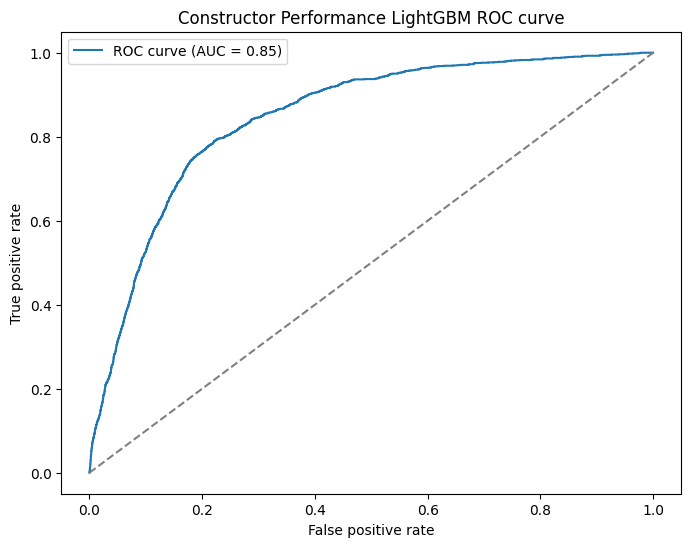

AUC:   0.8463  (baseline: 0.79)
Brier: 0.1167  (baseline: 0.12)


In [37]:
EvaluateModel(
    model,
    all_labels=all_labels,
    all_preds=all_preds, 
    cg_title="Calibration Curve of Constructor Features", 
    roc_title="Constructor Performance LightGBM ROC curve")

### Constructor Reliablity

To determine reliability, we want to see over the last X races, what is the ratio of times that a driver had to retire due to mechanical issues? To start we need to get the list of status ID's that correspond to mechanical failure

In [38]:
non_mechanical_statuses = [
    # Finished / classified
    "Finished",
    "+1 Lap", "+2 Laps", "+3 Laps", "+4 Laps", "+5 Laps",
    "+6 Laps", "+7 Laps", "+8 Laps", "+9 Laps", "+10 Laps",
    "+11 Laps", "+12 Laps", "+13 Laps", "+14 Laps", "+15 Laps",
    "+16 Laps", "+17 Laps", "+18 Laps", "+19 Laps", "+20 Laps",
    "+21 Laps", "+22 Laps", "+23 Laps", "+24 Laps", "+25 Laps",
    "+26 Laps", "+29 Laps", "+30 Laps", "+38 Laps", "+42 Laps",
    "+44 Laps", "+46 Laps", "+49 Laps",

    # Racing incidents
    "Accident", "Collision", "Collision damage", "Spun off", "Fatal accident",

    # Driver / personal
    "Physical", "Injured", "Injury", "Driver unwell", "Eye injury",
    "Illness", "Safety belt", "Driver Seat", "Seat",

    # Regulatory / administrative
    "Disqualified", "Excluded", "Underweight", "107% Rule",
    "Did not qualify", "Did not prequalify", "Not classified",
    "Withdrew", "Not restarted",

    # Ambiguous — excluded to keep data clean
    "Retired", "Damage", "Debris", "Fire", "Safety", "Safety concerns",

    # Pit / logistics
    "Fuel Rig",
]

mechanical_dnf_ids = status_df[
    ~status_df["status"].isin(non_mechanical_statuses)
]["statusId"]

In [39]:
training_base_driver_en_3_data_df = (
    training_base_driver_en_2_data_df
    .sort_values(["year", "round"])
    .copy()
)

training_base_driver_en_3_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10
26751,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,1999-05-30,Chinese,0,0.000000,0.0,0.0,0.000000,0.0,0.0
26748,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2001-04-06,Australian,0,0.333333,0.2,0.5,0.333333,0.2,0.5
26755,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2002-02-11,New Zealander,0,0.000000,0.0,0.0,0.000000,0.0,0.0
26757,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2003-05-27,Argentinian,0,0.000000,0.0,0.0,0.000000,0.0,0.0
26753,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2003-01-20,Australian,0,0.000000,0.0,0.0,0.000000,0.2,0.1


In [40]:
training_base_driver_en_3_data_df["mechanicalDNF"] = np.where(training_base_driver_en_3_data_df["statusId"].isin(mechanical_dnf_ids), 1, 0)
training_base_driver_en_3_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,mechanicalDNF
6483,6484,305,55,6,12.0,6,1991,1,33,United States Grand Prix,...,1964-06-11,French,0,0.0,0.0,0.0,0.333333,0.6,0.7,1
6484,6485,305,57,32,13.0,5,1991,1,33,United States Grand Prix,...,1968-09-28,Finnish,0,0.0,0.0,0.0,0.000000,0.0,0.0,1
6490,6491,305,77,1,NaN,48,1991,1,33,United States Grand Prix,...,1959-08-27,Austrian,0,0.0,0.0,0.0,0.333333,0.2,0.2,1
6478,6479,305,78,40,7.0,13,1991,1,33,United States Grand Prix,...,1964-03-19,Italian,0,0.0,0.0,0.0,0.000000,0.0,0.0,0
6495,6496,305,81,18,NaN,6,1991,1,33,United States Grand Prix,...,1968-01-13,Italian,0,0.0,0.0,0.0,0.000000,0.0,0.0,1


In [41]:
training_base_driver_en_3_data_df["constructor_mechanical_dnf_rate_5"] = (
    training_base_driver_en_3_data_df.groupby("constructorId", observed=True)["mechanicalDNF"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

training_base_driver_en_3_data_df["constructor_mechanical_dnf_rate_5"] = training_base_driver_en_3_data_df["constructor_mechanical_dnf_rate_5"].fillna(0)
training_base_driver_en_3_data_df = training_base_driver_en_3_data_df.drop(columns=["mechanicalDNF"])
training_base_driver_en_3_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5
6483,6484,305,55,6,12.0,6,1991,1,33,United States Grand Prix,...,1964-06-11,French,0,0.0,0.0,0.0,0.333333,0.6,0.7,0.0
6484,6485,305,57,32,13.0,5,1991,1,33,United States Grand Prix,...,1968-09-28,Finnish,0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
6490,6491,305,77,1,NaN,48,1991,1,33,United States Grand Prix,...,1959-08-27,Austrian,0,0.0,0.0,0.0,0.333333,0.2,0.2,0.0
6478,6479,305,78,40,7.0,13,1991,1,33,United States Grand Prix,...,1964-03-19,Italian,0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
6495,6496,305,81,18,NaN,6,1991,1,33,United States Grand Prix,...,1968-01-13,Italian,0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


#### Evaluating Constructor Reliability Features

In [42]:
engineered_features = [
    "driverId", "constructorId", "circuitId", "year", "round",
    "driver_podium_rate_3", "driver_podium_rate_5", "driver_podium_rate_10",
    "constructor_podium_rate_3", "constructor_podium_rate_5", "constructor_podium_rate_10",
    "constructor_mechanical_dnf_rate_5"
]

engineered_cat_features = ["driverId", "constructorId", "circuitId"]

folds = GenerateFolds(training_base_driver_en_3_data_df, train_window=10, val_window=1)
X, y = GenXy(training_base_driver_en_3_data_df, engineered_features, engineered_cat_features)

In [43]:
model, all_preds, all_labels = TrainModel(X, y, training_base_driver_en_3_data_df, folds, {
    "run_name": "lgbm-constructor-rel-performance-walk-forward-scaled",
    "description": "LightGBM with rolling walk-forward cross-validation, with driver and constructor and constructor reliability stats",
    "tags": {
        "model_type": "lightgbm",
        "feature_set": "driverPerformance + constructorPerformance + constructorReliability",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    },
    "model_params": {
        "objective": "binary",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 20,
        "scale_pos_weight": 5.67,
        "verbose": -1,
    }
})

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/9b21616248294ec493308423d6ef2382
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/6e343e5c20c74e589391c23dcc324a09
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/35cf3d5d8ff544538ef00eb602e87b59
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/2973f95699c043338796068bb14c69c8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/01 09:09:35 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-constructor-rel-performance-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/dc29b517ef144ade90c251a069b8d3fd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


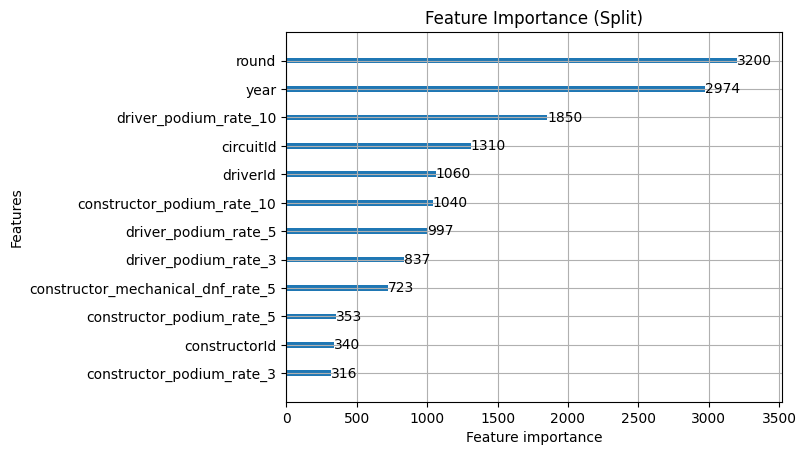

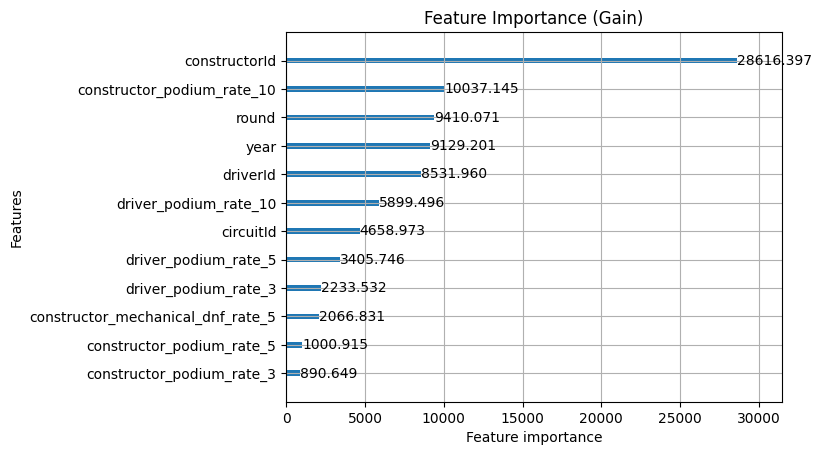

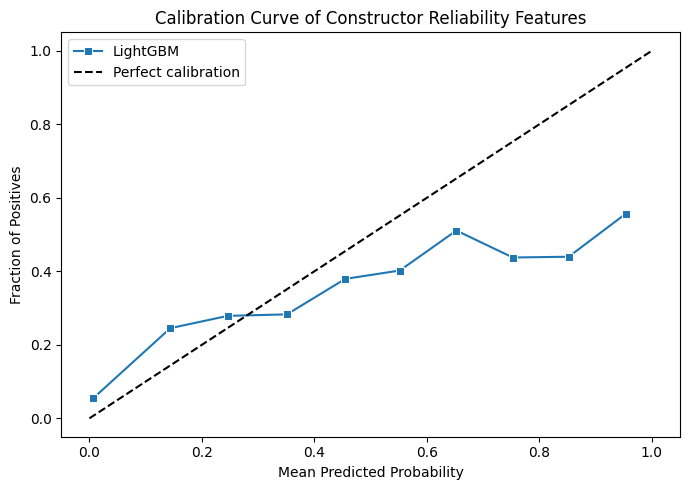

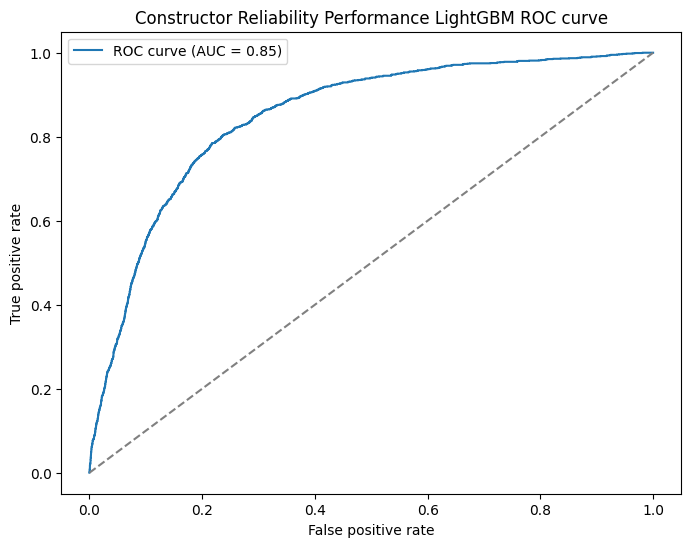

AUC:   0.8480  (baseline: 0.79)
Brier: 0.1145  (baseline: 0.12)


In [44]:
EvaluateModel(
    model,
    all_labels=all_labels,
    all_preds=all_preds, 
    cg_title="Calibration Curve of Constructor Reliability Features", 
    roc_title="Constructor Reliability Performance LightGBM ROC curve")

### Driver Profile

We can expand out the detail of the driver a little more by giving the model more context of a drivers experience. We believe that drivers performance forms an inverted U as they age so we can capture that, total racing experience also plays a factor as well as drivers having more experience at a particular circuit as well

In [45]:
training_base_driver_en_4_data_df = (
    training_base_driver_en_3_data_df
    .sort_values(["year", "round"])
    .copy()
)

training_base_driver_en_4_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5
26751,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,1999-05-30,Chinese,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
26748,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,2001-04-06,Australian,0,0.333333,0.2,0.5,0.333333,0.2,0.5,0.0
26755,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,2002-02-11,New Zealander,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
26757,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,2003-05-27,Argentinian,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.2
26753,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,2003-01-20,Australian,0,0.000000,0.0,0.0,0.000000,0.2,0.1,0.2


In [46]:
training_base_driver_en_4_data_df = pd.merge(
    left=training_base_driver_en_4_data_df,
    right=race_df[["raceId", "date"]],
    on="raceId"
).rename(columns={"date_y":"raceDate"})

training_base_driver_en_4_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,raceDate
0,6484,305,55,6,12.0,6,1991,1,33,United States Grand Prix,...,French,0,0.0,0.0,0.0,0.333333,0.6,0.7,0.0,1991-03-10
1,6485,305,57,32,13.0,5,1991,1,33,United States Grand Prix,...,Finnish,0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1991-03-10
2,6491,305,77,1,NaN,48,1991,1,33,United States Grand Prix,...,Austrian,0,0.0,0.0,0.0,0.333333,0.2,0.2,0.0,1991-03-10
3,6479,305,78,40,7.0,13,1991,1,33,United States Grand Prix,...,Italian,0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1991-03-10
4,6496,305,81,18,NaN,6,1991,1,33,United States Grand Prix,...,Italian,0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1991-03-10


In [47]:
training_base_driver_en_4_data_df["driverAge"] = (training_base_driver_en_4_data_df["raceDate"] - training_base_driver_en_4_data_df["dob"]).dt.days / 365.25 
training_base_driver_en_4_data_df = training_base_driver_en_4_data_df.drop(columns="raceDate")
training_base_driver_en_4_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge
13782,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,Chinese,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,25.527721
13783,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,Australian,0,0.333333,0.2,0.5,0.333333,0.2,0.5,0.0,23.674196
13784,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,New Zealander,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,22.822724
13785,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,Argentinian,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.2,21.535934
13786,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,Australian,0,0.000000,0.0,0.0,0.000000,0.2,0.1,0.2,21.883641


In [48]:
training_base_driver_en_4_data_df["driver_experience"] = (
    training_base_driver_en_4_data_df.groupby("driverId", observed=True).cumcount())

training_base_driver_en_4_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience
13782,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,25.527721,67
13783,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,0,0.333333,0.2,0.5,0.333333,0.2,0.5,0.0,23.674196,45
13784,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,22.822724,10
13785,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.2,21.535934,8
13786,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0,0.000000,0.0,0.0,0.000000,0.2,0.1,0.2,21.883641,0


In [49]:
training_base_driver_en_4_data_df["driver_circuit_podium_rate"] = (
    training_base_driver_en_4_data_df.groupby(["driverId", "circuitId"], observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

training_base_driver_en_4_data_df["driver_circuit_podium_rate"] = training_base_driver_en_4_data_df["driver_circuit_podium_rate"].fillna(0)
training_base_driver_en_4_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate
0,6484,305,55,6,12.0,6,1991,1,33,United States Grand Prix,...,0.0,0.0,0.0,0.333333,0.6,0.7,0.0,26.743326,0,0.0
1,6485,305,57,32,13.0,5,1991,1,33,United States Grand Prix,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,22.444901,0,0.0
2,6491,305,77,1,NaN,48,1991,1,33,United States Grand Prix,...,0.0,0.0,0.0,0.333333,0.2,0.2,0.0,31.534565,0,0.0
3,6479,305,78,40,7.0,13,1991,1,33,United States Grand Prix,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,26.973306,0,0.0
4,6496,305,81,18,NaN,6,1991,1,33,United States Grand Prix,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,23.154004,0,0.0


#### Evaluating Driver Profile

In [50]:
engineered_features = [
    "driverId", "constructorId", "circuitId", "year", "round",
    "driver_podium_rate_3", "driver_podium_rate_5", "driver_podium_rate_10",
    "constructor_podium_rate_3", "constructor_podium_rate_5", "constructor_podium_rate_10",
    "constructor_mechanical_dnf_rate_5", "driverAge", "driver_experience", "driver_circuit_podium_rate"
]

engineered_cat_features = ["driverId", "constructorId", "circuitId"]

folds = GenerateFolds(training_base_driver_en_4_data_df, train_window=10, val_window=1)
X, y = GenXy(training_base_driver_en_4_data_df, engineered_features, engineered_cat_features)

In [51]:
model, all_preds, all_labels = TrainModel(X, y, training_base_driver_en_4_data_df, folds, {
    "run_name": "lgbm-constructor-rel-driver-profile-performance-walk-forward-scaled",
    "description": "LightGBM with rolling walk-forward cross-validation, with driver and constructor, reliability and driver profile stats",
    "tags": {
        "model_type": "lightgbm",
        "feature_set": "driverPerformance + constructorPerformance + constructorReliability + driverProfile",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    },
    "model_params": {
        "objective": "binary",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 20,
        "scale_pos_weight": 5.67,
        "verbose": -1,
    }
})

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/41a934f3925b4faf8d5b4a01702b677c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/88ee6d06301243c292e9f1f8f0d111ef
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/d695cbc611c74907b3d7b2de60bbbfe5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/971e73d584364839af481336666d3b82
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/01 09:09:57 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-constructor-rel-driver-profile-performance-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/e2135a88a4704ecba4f78d8fce5f200b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


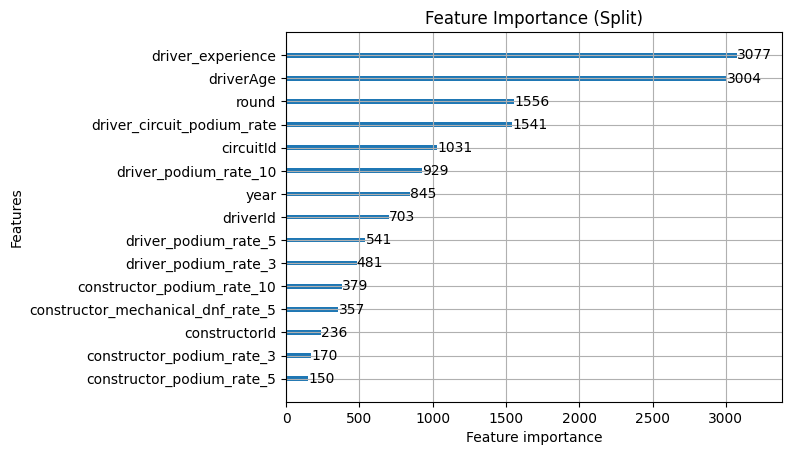

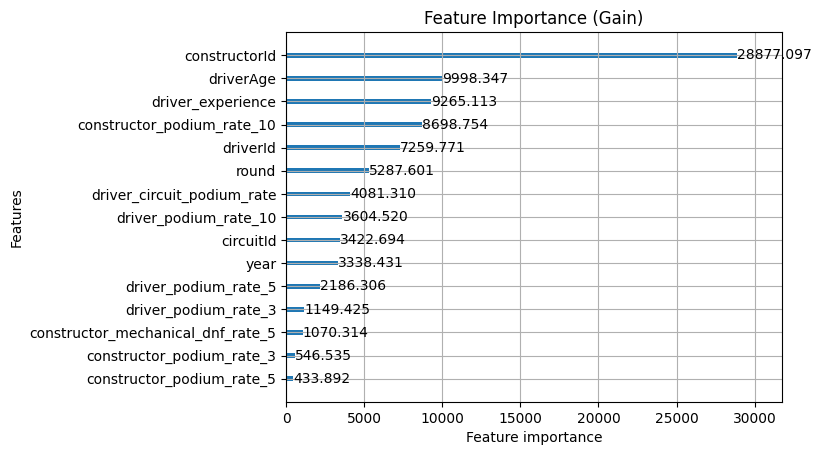

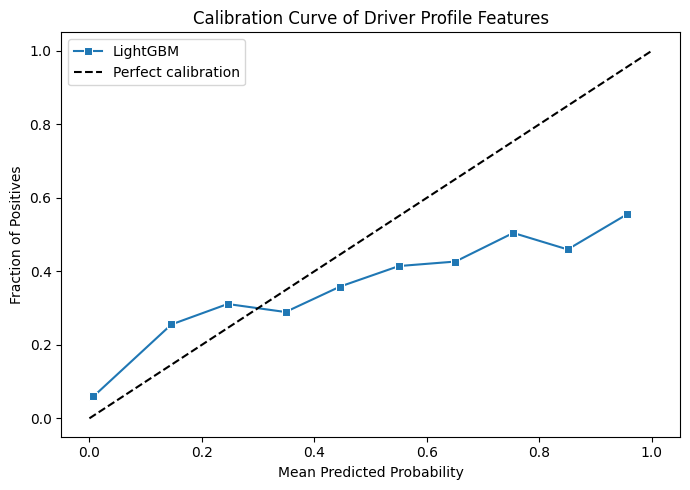

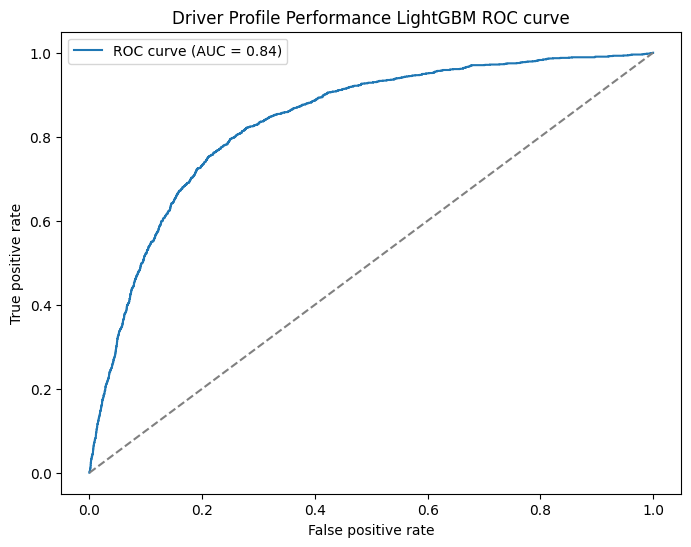

AUC:   0.8359  (baseline: 0.79)
Brier: 0.1141  (baseline: 0.12)


In [52]:
EvaluateModel(
    model,
    all_labels=all_labels,
    all_preds=all_preds, 
    cg_title="Calibration Curve of Driver Profile Features", 
    roc_title="Driver Profile Performance LightGBM ROC curve")

So there is good news:
* Driver experience
* Driver age

are both at the top of spplits, it's leaning on them a lot as a general purpose discriminator. Driver circuit podium rate is also performing surprisingly well given how specific it is

Constructor rates are still surprisingly weak. and constructor ID is still dominatating so at the moment the model is still preferring to know *who* the constructor is rather than their recent form. So there are probably features here to unpack still

constructor mechanical DNF rate is also surprisingly holding it's own as well showing that it has real predictive power even though it's quite specific

A problem we have is that age and experience are highly correlated, they're both proxies for career stage really so they're probably splitting significant signal between them.


### Season Context
Two other features that we can grab to see how well the season is going so far are:
* Driver season podium rate - What's the drivers podium rate for this season. Might give us more insights to how the car is performing this seaon for the driver
* Championship position - The driver championship standings before this reace. It's a composite signal of how the driver is performing this season


Why are we not doing the constructors championship as well as a signal? It's got way too much overlap with the drivers championship. We don't get anything more because we've already got the average of the two drivers anyway

In [53]:
training_base_driver_en_5_data_df = (
    training_base_driver_en_4_data_df
    .sort_values(["year", "round"])
    .copy()
)

training_base_driver_en_5_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate
13782,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,25.527721,67,0.0
13783,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,0.333333,0.2,0.5,0.333333,0.2,0.5,0.0,23.674196,45,0.0
13784,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,22.822724,10,0.0
13785,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.2,21.535934,8,0.0
13786,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.000000,0.0,0.0,0.000000,0.2,0.1,0.2,21.883641,0,0.0


In [54]:
training_base_driver_en_5_data_df = pd.merge(
    left=training_base_driver_en_5_data_df,
    right=res_df[["resultId", "points"]],
    on="resultId"
)

training_base_driver_en_5_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate,points
13782,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.0,0.000000,0.0,0.0,0.0,25.527721,67,0.0,0.0
13783,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,0.2,0.5,0.333333,0.2,0.5,0.0,23.674196,45,0.0,1.0
13784,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.0,0.000000,0.0,0.0,0.0,22.822724,10,0.0,0.0
13785,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.0,0.000000,0.0,0.0,0.2,21.535934,8,0.0,0.0
13786,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.0,0.000000,0.2,0.1,0.2,21.883641,0,0.0,0.0


In [55]:
training_base_driver_en_5_data_df["cumulative_points"] = (
    training_base_driver_en_5_data_df.groupby(["year","driverId"], observed=True)["points"]
        .transform(lambda x: x.shift(1).cumsum()))

training_base_driver_en_5_data_df["driver_championship_position"] = training_base_driver_en_5_data_df.groupby("raceId")["cumulative_points"].rank(ascending=False, method="min")

training_base_driver_en_5_data_df = training_base_driver_en_5_data_df.drop(columns=["cumulative_points", "points"])

# Unlike the others, we've got to be careful we fill it with the *last* position instead of zero, otherwise it makes it look better not worse
training_base_driver_en_5_data_df["driver_championship_position"] = (
    training_base_driver_en_5_data_df.groupby("raceId")["driver_championship_position"]
    .transform(lambda x: x.fillna(len(x)))
)

training_base_driver_en_5_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate,driver_championship_position
0,6484,305,55,6,12.0,6,1991,1,33,United States Grand Prix,...,0.0,0.0,0.333333,0.6,0.7,0.0,26.743326,0,0.0,34.0
1,6485,305,57,32,13.0,5,1991,1,33,United States Grand Prix,...,0.0,0.0,0.000000,0.0,0.0,0.0,22.444901,0,0.0,34.0
2,6491,305,77,1,NaN,48,1991,1,33,United States Grand Prix,...,0.0,0.0,0.333333,0.2,0.2,0.0,31.534565,0,0.0,34.0
3,6479,305,78,40,7.0,13,1991,1,33,United States Grand Prix,...,0.0,0.0,0.000000,0.0,0.0,0.0,26.973306,0,0.0,34.0
4,6496,305,81,18,NaN,6,1991,1,33,United States Grand Prix,...,0.0,0.0,0.000000,0.0,0.0,0.0,23.154004,0,0.0,34.0


In [56]:
training_base_driver_en_5_data_df["driver_season_podium_rate"] = (
    training_base_driver_en_5_data_df.groupby(["year", "driverId"], observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

training_base_driver_en_5_data_df["driver_season_podium_rate"] = training_base_driver_en_5_data_df["driver_season_podium_rate"].fillna(0)
training_base_driver_en_5_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate,driver_championship_position,driver_season_podium_rate
13782,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.000000,0.0,0.0,0.0,25.527721,67,0.0,17.0,0.000000
13783,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,0.5,0.333333,0.2,0.5,0.0,23.674196,45,0.0,4.0,0.347826
13784,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.000000,0.0,0.0,0.0,22.822724,10,0.0,17.0,0.000000
13785,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.000000,0.0,0.0,0.2,21.535934,8,0.0,16.0,0.000000
13786,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.000000,0.2,0.1,0.2,21.883641,0,0.0,20.0,0.000000


#### Evaluating Season Context 

In [57]:
engineered_features = [
    "driverId", "constructorId", "circuitId", "year", "round",
    "driver_podium_rate_3", "driver_podium_rate_5", "driver_podium_rate_10",
    "constructor_podium_rate_3", "constructor_podium_rate_5", "constructor_podium_rate_10",
    "constructor_mechanical_dnf_rate_5", "driverAge", "driver_experience", "driver_circuit_podium_rate",
    "driver_championship_position", "driver_season_podium_rate"
]

engineered_cat_features = ["driverId", "constructorId", "circuitId"]

folds = GenerateFolds(training_base_driver_en_5_data_df, train_window=10, val_window=1)
X, y = GenXy(training_base_driver_en_5_data_df, engineered_features, engineered_cat_features)

In [58]:
model, all_preds, all_labels = TrainModel(X, y, training_base_driver_en_5_data_df, folds, {
    "run_name": "lgbm-constructor-rel-driver-profile-season-performance-walk-forward-scaled",
    "description": "LightGBM with rolling walk-forward cross-validation, with driver and constructor, reliability, driver profile stats and driver season context",
    "tags": {
        "model_type": "lightgbm",
        "feature_set": "driverPerformance + constructorPerformance + constructorReliability + driverProfile + seasonContext",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    },
    "model_params": {
        "objective": "binary",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 20,
        "scale_pos_weight": 5.67,
        "verbose": -1,
    }
})

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/0782b72edbbe40fcad675b5461cf50ec
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/226d8358793a4453a2366d4896404cc7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/bb2db196749e454d9b025368edc2dc06
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/c7d547b2ed004d68b5e1286fca8fb5df
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/01 09:10:19 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-constructor-rel-driver-profile-season-performance-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/4d455214d0524ea5949c8ffbb8897808
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


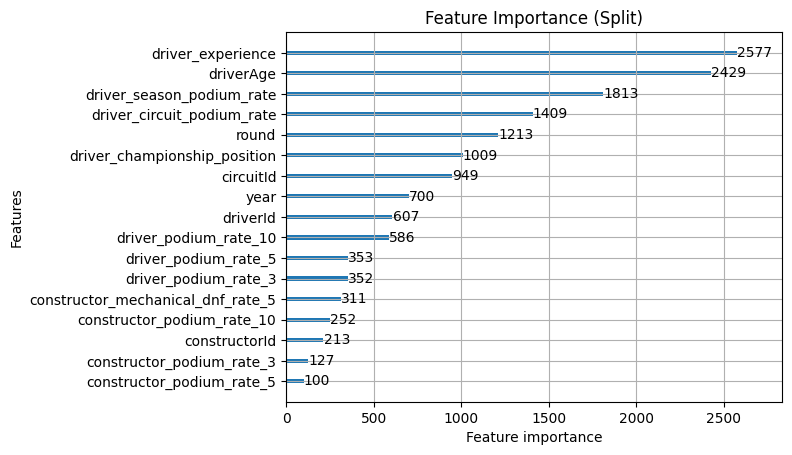

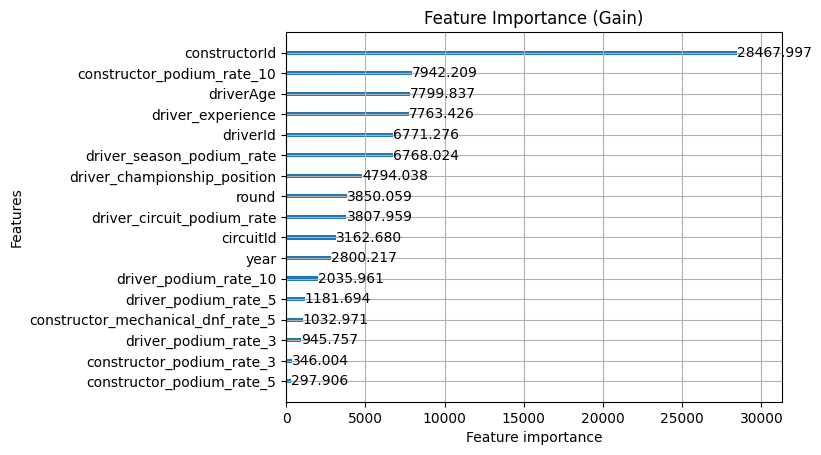

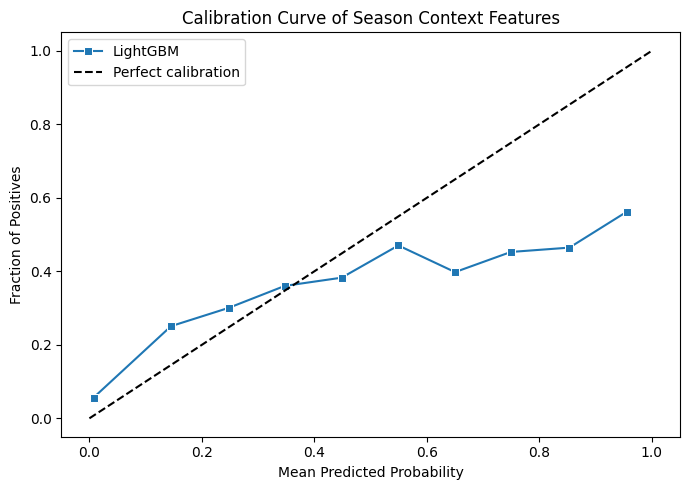

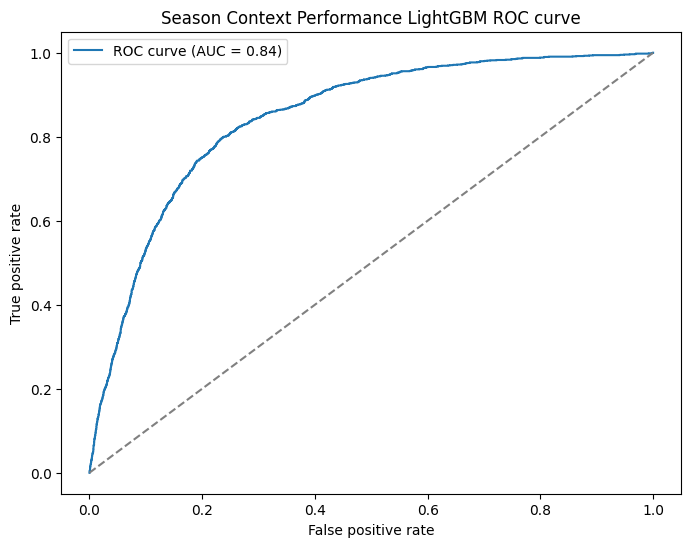

AUC:   0.8450  (baseline: 0.79)
Brier: 0.1132  (baseline: 0.12)


In [59]:
EvaluateModel(
    model,
    all_labels=all_labels,
    all_preds=all_preds, 
    cg_title="Calibration Curve of Season Context Features", 
    roc_title="Season Context Performance LightGBM ROC curve")

### Race & Circuit Context


In [60]:
training_base_driver_en_6_data_df = (
    training_base_driver_en_5_data_df
    .sort_values(["year", "round"])
    .copy()
)

training_base_driver_en_6_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate,driver_championship_position,driver_season_podium_rate
13782,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.000000,0.0,0.0,0.0,25.527721,67,0.0,17.0,0.000000
13783,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,0.5,0.333333,0.2,0.5,0.0,23.674196,45,0.0,4.0,0.347826
13784,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.000000,0.0,0.0,0.0,22.822724,10,0.0,17.0,0.000000
13785,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.000000,0.0,0.0,0.2,21.535934,8,0.0,16.0,0.000000
13786,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.000000,0.2,0.1,0.2,21.883641,0,0.0,20.0,0.000000


In [61]:
regulation_era_map = {year: era for era, years in {
    "v10": range(1991, 2006),
    "v8": range(2006, 2014),
    "hybrid": range(2014, 2022),
    "ground_effect": range(2022, 2026),
    "battery": range(2026, 2030),
}.items() for year in years}

training_base_driver_en_6_data_df["regulation_era"] = (
    training_base_driver_en_6_data_df["year"].map(regulation_era_map)
)

training_base_driver_en_6_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate,driver_championship_position,driver_season_podium_rate,regulation_era
13782,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.000000,0.0,0.0,0.0,25.527721,67,0.0,17.0,0.000000,ground_effect
13783,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,0.333333,0.2,0.5,0.0,23.674196,45,0.0,4.0,0.347826,ground_effect
13784,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,0.000000,0.0,0.0,0.0,22.822724,10,0.0,17.0,0.000000,ground_effect
13785,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,0.000000,0.0,0.0,0.2,21.535934,8,0.0,16.0,0.000000,ground_effect
13786,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.000000,0.2,0.1,0.2,21.883641,0,0.0,20.0,0.000000,ground_effect


In [62]:
circuit_type_map = {
    # Street circuits — public roads, temporary infrastructure
    6:  "street",   # Monaco
    12: "street",   # Valencia
    15: "street",   # Marina Bay (Singapore)
    29: "street",   # Adelaide
    33: "street",   # Phoenix
    37: "street",   # Detroit
    42: "street",   # Dallas (Fair Park)
    43: "street",   # Long Beach
    44: "street",   # Las Vegas (old)
    59: "street",   # Boavista (Porto)
    67: "street",   # Pedralbes (Barcelona)
    73: "street",   # Baku
    77: "street",   # Jeddah
    80: "street",   # Las Vegas Strip
    81: "street",   # Madring (Madrid)

    # Hybrid — semi-permanent or built on non-racing infrastructure
    71: "hybrid",   # Sochi (Olympic Park)
    79: "hybrid",   # Miami (Hard Rock Stadium complex)

    # Permanent — purpose-built racing circuits
    1:  "permanent",  # Albert Park (Melbourne) — technically a park but purpose-configured
    2:  "permanent",  # Sepang
    3:  "permanent",  # Bahrain
    4:  "permanent",  # Catalunya
    5:  "permanent",  # Istanbul Park
    7:  "permanent",  # Villeneuve (Montreal) — park circuit but permanent config
    8:  "permanent",  # Magny-Cours
    9:  "permanent",  # Silverstone
    10: "permanent",  # Hockenheimring
    11: "permanent",  # Hungaroring
    13: "permanent",  # Spa
    14: "permanent",  # Monza
    16: "permanent",  # Fuji
    17: "permanent",  # Shanghai
    18: "permanent",  # Interlagos
    19: "permanent",  # Indianapolis
    20: "permanent",  # Nurburgring
    21: "permanent",  # Imola
    22: "permanent",  # Suzuka
    24: "permanent",  # Yas Marina
    25: "permanent",  # Buenos Aires
    26: "permanent",  # Jerez
    27: "permanent",  # Estoril
    28: "permanent",  # Okayama
    30: "permanent",  # Kyalami
    31: "permanent",  # Donington
    32: "permanent",  # Rodriguez (Mexico City)
    34: "permanent",  # Paul Ricard
    35: "permanent",  # Yeongam (Korea)
    36: "permanent",  # Jacarepagua
    38: "permanent",  # Brands Hatch
    39: "permanent",  # Zandvoort
    40: "permanent",  # Zolder
    41: "permanent",  # Dijon
    45: "permanent",  # Jarama
    46: "permanent",  # Watkins Glen
    47: "permanent",  # Anderstorp
    48: "permanent",  # Mosport
    49: "permanent",  # Montjuic
    50: "permanent",  # Nivelles
    51: "permanent",  # Charade
    52: "permanent",  # Mont-Tremblant
    53: "permanent",  # Rouen-Les-Essarts
    54: "permanent",  # Le Mans (Bugatti)
    55: "permanent",  # Reims
    56: "permanent",  # Prince George
    57: "permanent",  # Zeltweg
    58: "permanent",  # Aintree
    60: "permanent",  # Riverside
    61: "permanent",  # AVUS
    62: "permanent",  # Monsanto
    63: "permanent",  # Sebring
    64: "permanent",  # Ain Diab
    65: "permanent",  # Pescara
    66: "permanent",  # Bremgarten
    68: "permanent",  # Buddh (India)
    69: "permanent",  # COTA (Austin)
    70: "permanent",  # Red Bull Ring
    75: "permanent",  # Portimao
    76: "permanent",  # Mugello
    78: "permanent",  # Losail (Qatar)
}

training_base_driver_en_6_data_df["circuit_type"] = (
    training_base_driver_en_6_data_df["circuitId"].map(circuit_type_map)
)

training_base_driver_en_6_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,constructor_podium_rate_5,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate,driver_championship_position,driver_season_podium_rate,regulation_era,circuit_type
13782,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.0,0.0,25.527721,67,0.0,17.0,0.000000,ground_effect,permanent
13783,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,0.2,0.5,0.0,23.674196,45,0.0,4.0,0.347826,ground_effect,permanent
13784,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.0,0.0,22.822724,10,0.0,17.0,0.000000,ground_effect,permanent
13785,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.0,0.2,21.535934,8,0.0,16.0,0.000000,ground_effect,permanent
13786,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.2,0.1,0.2,21.883641,0,0.0,20.0,0.000000,ground_effect,permanent


In [63]:
training_base_driver_en_6_data_df = pd.merge(
    left=training_base_driver_en_6_data_df,
    right=circuit_df[["circuitId", "country"]],
    on="circuitId"
)

training_base_driver_en_6_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate,driver_championship_position,driver_season_podium_rate,regulation_era,circuit_type,country
0,6484,305,55,6,12.0,6,1991,1,33,United States Grand Prix,...,0.7,0.0,26.743326,0,0.0,34.0,0.0,v10,street,USA
1,6485,305,57,32,13.0,5,1991,1,33,United States Grand Prix,...,0.0,0.0,22.444901,0,0.0,34.0,0.0,v10,street,USA
2,6491,305,77,1,NaN,48,1991,1,33,United States Grand Prix,...,0.2,0.0,31.534565,0,0.0,34.0,0.0,v10,street,USA
3,6479,305,78,40,7.0,13,1991,1,33,United States Grand Prix,...,0.0,0.0,26.973306,0,0.0,34.0,0.0,v10,street,USA
4,6496,305,81,18,NaN,6,1991,1,33,United States Grand Prix,...,0.0,0.0,23.154004,0,0.0,34.0,0.0,v10,street,USA


In [64]:
nationality_country_map = {
    "British": "UK",
    "German": "Germany",
    "Spanish": "Spain",
    "Finnish": "Finland",
    "Brazilian": "Brazil",
    "Australian": "Australia",
    "French": "France",
    "Italian": "Italy",
    "Austrian": "Austria",
    "Dutch": "Netherlands",
    "Belgian": "Belgium",
    "Canadian": "Canada",
    "American": "USA",
    "Japanese": "Japan",
    "New Zealander": "New Zealand",
    "Mexican": "Mexico",
    "Monegasque": "Monaco",
    "Swiss": "Switzerland",
    "Danish": "Denmark",
    "Swedish": "Sweden",
    "Argentine": "Argentina",
    "Portuguese": "Portugal",
    "South African": "South Africa",
    "Colombian": "Colombia",
    "Venezuelan": "Venezuela",
    "Czech": "Czech Republic",
    "Hungarian": "Hungary",
    "Russian": "Russia",
    "Polish": "Poland",
    "Malaysian": "Malaysia",
    "Indian": "India",
    "Chinese": "China",
    "Thai": "Thailand",
    "Indonesian": "Indonesia",
    "Bahraini": "Bahrain",
    "Emirati": "UAE",
    "Saudi Arabian": "Saudi Arabia",
    "Qatari": "Qatar",
    "Azerbaijani": "Azerbaijan",
    "Irish": "Ireland",
    "Romanian": "Romania",
    "Chilean": "Chile",
    "Uruguayan": "Uruguay",
    "Liechtensteiner": "Liechtenstein",
}

training_base_driver_en_6_data_df["is_home_race"] = (
    training_base_driver_en_6_data_df["nationality"].map(nationality_country_map)
    == training_base_driver_en_6_data_df["country"]
).astype(int)

training_base_driver_en_6_data_df = training_base_driver_en_6_data_df.drop(columns=["country"])

training_base_driver_en_6_data_df.tail()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,constructor_podium_rate_10,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate,driver_championship_position,driver_season_podium_rate,regulation_era,circuit_type,is_home_race
13782,26757,1144,855,15,13.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.0,25.527721,67,0.0,17.0,0.000000,ground_effect,permanent,0
13783,26754,1144,857,1,10.0,1,2024,24,24,Abu Dhabi Grand Prix,...,0.5,0.0,23.674196,45,0.0,4.0,0.347826,ground_effect,permanent,0
13784,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.0,22.822724,10,0.0,17.0,0.000000,ground_effect,permanent,0
13785,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,...,0.0,0.2,21.535934,8,0.0,16.0,0.000000,ground_effect,permanent,0
13786,26759,1144,862,214,15.0,11,2024,24,24,Abu Dhabi Grand Prix,...,0.1,0.2,21.883641,0,0.0,20.0,0.000000,ground_effect,permanent,0


In [65]:
training_base_driver_en_6_data_df["grid_size"] = (
    training_base_driver_en_6_data_df.groupby("raceId")["driverId"]
    .transform("nunique")
)

training_base_driver_en_6_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,...,constructor_mechanical_dnf_rate_5,driverAge,driver_experience,driver_circuit_podium_rate,driver_championship_position,driver_season_podium_rate,regulation_era,circuit_type,is_home_race,grid_size
0,6484,305,55,6,12.0,6,1991,1,33,United States Grand Prix,...,0.0,26.743326,0,0.0,34.0,0.0,v10,street,0,34
1,6485,305,57,32,13.0,5,1991,1,33,United States Grand Prix,...,0.0,22.444901,0,0.0,34.0,0.0,v10,street,0,34
2,6491,305,77,1,NaN,48,1991,1,33,United States Grand Prix,...,0.0,31.534565,0,0.0,34.0,0.0,v10,street,0,34
3,6479,305,78,40,7.0,13,1991,1,33,United States Grand Prix,...,0.0,26.973306,0,0.0,34.0,0.0,v10,street,0,34
4,6496,305,81,18,NaN,6,1991,1,33,United States Grand Prix,...,0.0,23.154004,0,0.0,34.0,0.0,v10,street,0,34


#### Evaluating Race & Circuit Context

In [66]:
engineered_features = [
    "driverId", "constructorId", "circuitId", "year", "round",
    "driver_podium_rate_3", "driver_podium_rate_5", "driver_podium_rate_10",
    "constructor_podium_rate_3", "constructor_podium_rate_5", "constructor_podium_rate_10",
    "constructor_mechanical_dnf_rate_5", "driverAge", "driver_experience", "driver_circuit_podium_rate",
    "driver_championship_position", "driver_season_podium_rate", "grid_size"
]

engineered_cat_features = ["driverId", "constructorId", "circuitId", "regulation_era", "is_home_race"]

folds = GenerateFolds(training_base_driver_en_6_data_df, train_window=10, val_window=1)
X, y = GenXy(training_base_driver_en_6_data_df, engineered_features, engineered_cat_features)

In [67]:
model, all_preds, all_labels = TrainModel(X, y, training_base_driver_en_6_data_df, folds, {
    "run_name": "lgbm-constructor-rel-driver-profile-season-circuit-performance-walk-forward-scaled",
    "description": "LightGBM with rolling walk-forward cross-validation, with driver and constructor, reliability, driver profile stats, driver season context and race and driver context",
    "tags": {
        "model_type": "lightgbm",
        "feature_set": "driverPerformance + constructorPerformance + constructorReliability + driverProfile + seasonContext + circuitContext",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    },
    "model_params": {
        "objective": "binary",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 20,
        "scale_pos_weight": 5.67,
        "verbose": -1,
    }
})

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/db07cfebc7c7466a9a9cc5588eb8de84
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/6ce3d5d4f4f74a609c53e60bcc404b7a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/b01f2a20f958449e8804c83f62932ff2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/79458df643bb4d43bd318133a70a707c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/01 09:10:41 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-constructor-rel-driver-profile-season-circuit-performance-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/e245ef6e8c904581a85e35971d28e2b5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


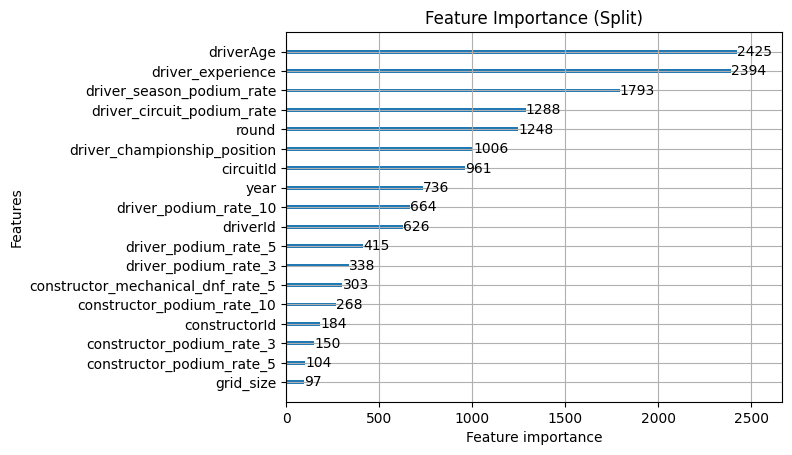

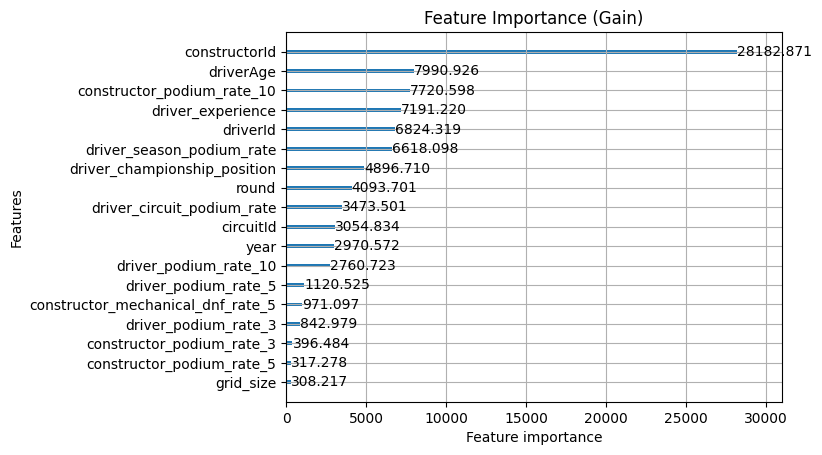

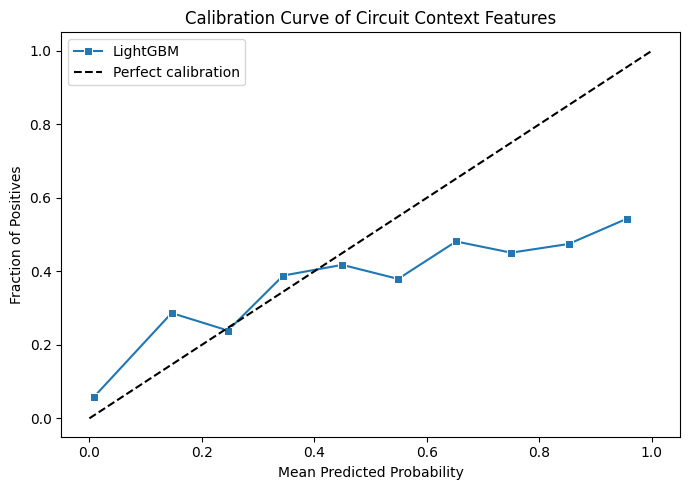

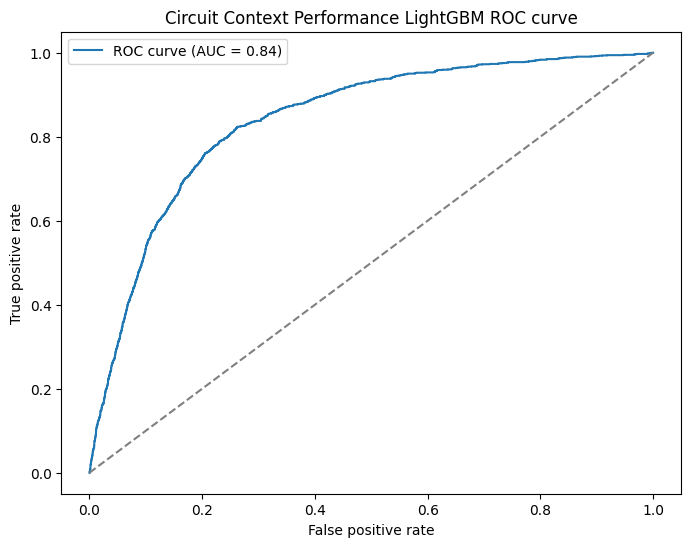

AUC:   0.8399  (baseline: 0.79)
Brier: 0.1140  (baseline: 0.12)


In [68]:
EvaluateModel(
    model,
    all_labels=all_labels,
    all_preds=all_preds, 
    cg_title="Calibration Curve of Circuit Context Features", 
    roc_title="Circuit Context Performance LightGBM ROC curve")

### Tuning the Model

In [69]:
!pip install optuna

In [70]:
final_f1_feature_df = training_base_driver_en_6_data_df.copy()

engineered_features = [
    "driverId", "constructorId", "circuitId", "year", "round",
    "driver_podium_rate_3", "driver_podium_rate_5", "driver_podium_rate_10",
    "constructor_podium_rate_3", "constructor_podium_rate_5", "constructor_podium_rate_10",
    "constructor_mechanical_dnf_rate_5", "driverAge", "driver_experience", "driver_circuit_podium_rate",
    "driver_championship_position", "driver_season_podium_rate", "grid_size"
]

engineered_cat_features = ["driverId", "constructorId", "circuitId", "regulation_era", "is_home_race"]

folds = GenerateFolds(final_f1_feature_df, train_window=10, val_window=1)
X, y = GenXy(final_f1_feature_df, engineered_features, engineered_cat_features)

In [71]:
import optuna

def objective(trial):
    params = {
        "objective": "binary",
        "verbose": -1,
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }

    fold_briers = []

    for fold, (train_years, val_years) in enumerate(folds):
        train_mask = final_f1_feature_df["year"].isin(train_years)
        val_mask   = final_f1_feature_df["year"].isin(val_years)

        X_train_fold, y_train_fold = X[train_mask], y[train_mask]
        X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_train_fold, y_train_fold)
        preds = model.predict_proba(X_val_fold)[:, 1]
        fold_briers.append(brier_score_loss(y_val_fold, preds))

    return sum(fold_briers) / len(fold_briers)

In [72]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Brier:", study.best_value)
print("Best params:", study.best_params)

[I 2026-05-01 09:10:45,178] A new study created in memory with name: no-name-96a6e4e3-b9d2-4388-8b50-cb2ede204edd
[I 2026-05-01 09:10:52,530] Trial 0 finished with value: 0.11409428280060328 and parameters: {'n_estimators': 305, 'learning_rate': 0.07572046880645444, 'num_leaves': 52, 'min_child_samples': 33, 'scale_pos_weight': 3.3200792157441312, 'subsample': 0.9376700297111725, 'colsample_bytree': 0.7658855298663183}. Best is trial 0 with value: 0.11409428280060328.
[I 2026-05-01 09:10:59,269] Trial 1 finished with value: 0.12331113321991245 and parameters: {'n_estimators': 470, 'learning_rate': 0.13008997049060453, 'num_leaves': 28, 'min_child_samples': 25, 'scale_pos_weight': 6.8129526924969515, 'subsample': 0.6497651264275838, 'colsample_bytree': 0.6804949184365844}. Best is trial 0 with value: 0.11409428280060328.
[I 2026-05-01 09:11:07,009] Trial 2 finished with value: 0.10522950116947631 and parameters: {'n_estimators': 508, 'learning_rate': 0.0364769304314083, 'num_leaves': 30

Best Brier: 0.08388430925999646
Best params: {'n_estimators': 141, 'learning_rate': 0.012528855142547582, 'num_leaves': 39, 'min_child_samples': 100, 'scale_pos_weight': 1.1890770693396244, 'subsample': 0.5568574539177875, 'colsample_bytree': 0.8018077499633975}


In [73]:
best_params = study.best_params
best_params["objective"] = "binary"
best_params["verbose"] = -1

model, all_preds, all_labels = TrainModel(X, y, final_f1_feature_df, folds, {
    "run_name": "lgbm-tuned-walk-forward",
    "description": "LightGBM with full feature set and Bayesian tuned hyperparameters",
    "tags": {
        "model_type": "lightgbm",
        "feature_set": "full",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    },
    "model_params": best_params
})

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/f3c28e80c166460bb3b848f2c686bbf3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/bdc1148d3abc4133b73411c7eda723c2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/5cd5e43425084f609b87c2bfb6285315
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/b20c6b9a26e648f99399631da122428a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/05/01 09:19:00 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-tuned-walk-forward at: http://127.0.0.1:5000/#/experiments/1/runs/cf5e652bd013403db43273551959e6ee
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


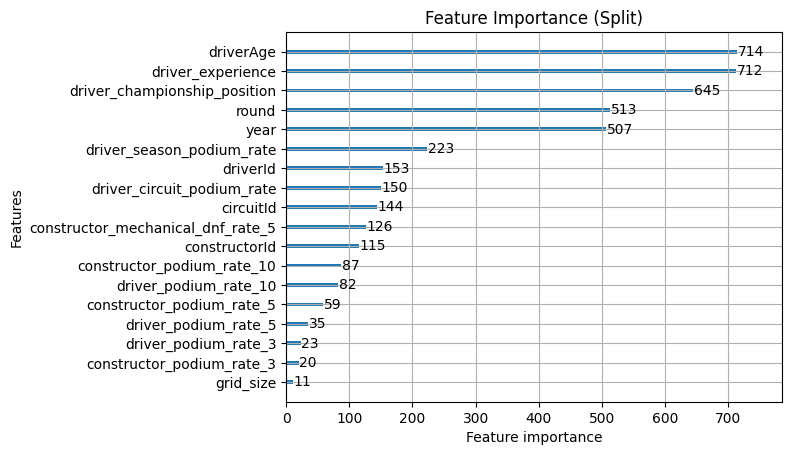

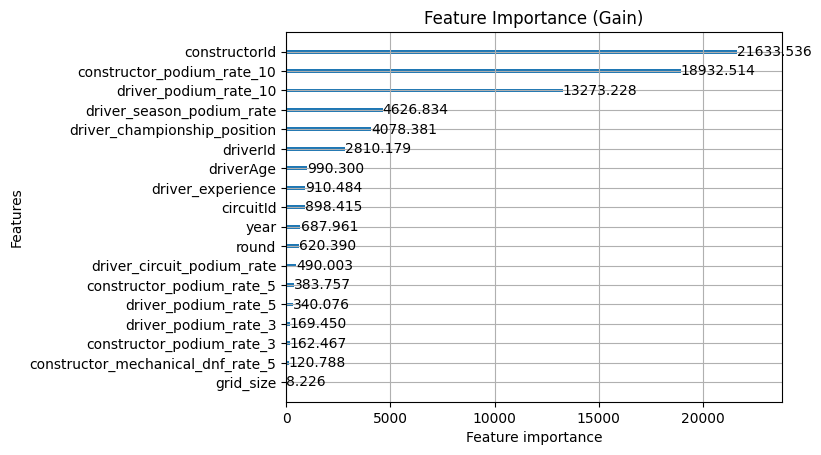

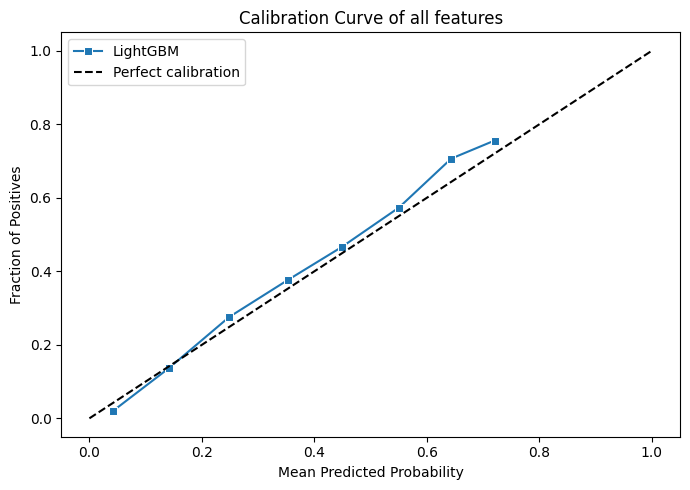

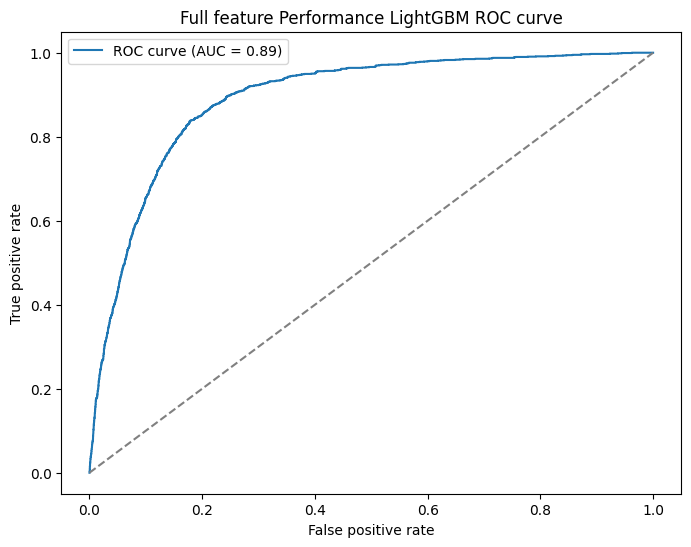

AUC:   0.8916  (baseline: 0.79)
Brier: 0.0834  (baseline: 0.12)


In [74]:
EvaluateModel(
    model,
    all_labels=all_labels,
    all_preds=all_preds, 
    cg_title="Calibration Curve of all features", 
    roc_title="Full feature Performance LightGBM ROC curve")